Using device: cuda
Starting iterative training: PINN + MMPDE adaptive sampling for Sine-Gordon

【Phase 1】Initial training with uniform sampling (3000 epochs)
Generated uniform collocation grid: 20×20×20 = 8000 points
Starting initial training...
Epoch [500/3000], Loss: 9.699226e-03, PDE: 2.825522e-03, IC: 2.515807e-04, BC: 4.357898e-04
Epoch [1000/3000], Loss: 2.817315e-03, PDE: 8.223018e-04, IC: 7.248668e-05, BC: 1.270146e-04
Epoch [1500/3000], Loss: 2.704910e-03, PDE: 6.385891e-04, IC: 1.290733e-04, BC: 7.755881e-05
Epoch [2000/3000], Loss: 1.430383e-03, PDE: 3.182999e-04, IC: 4.555664e-05, BC: 6.565166e-05
Epoch [2500/3000], Loss: 6.215336e-04, PDE: 2.035514e-04, IC: 1.437334e-05, BC: 2.742487e-05
Epoch [3000/3000], Loss: 4.494010e-04, PDE: 1.544953e-04, IC: 1.027267e-05, BC: 1.921790e-05
Initial training completed, current loss: 4.494010e-04

【Phase 2】Iteration 1: MMPDE adaptive sampling + continue training
Performing MMPDE adaptive sampling based on current PINN model...
Generated

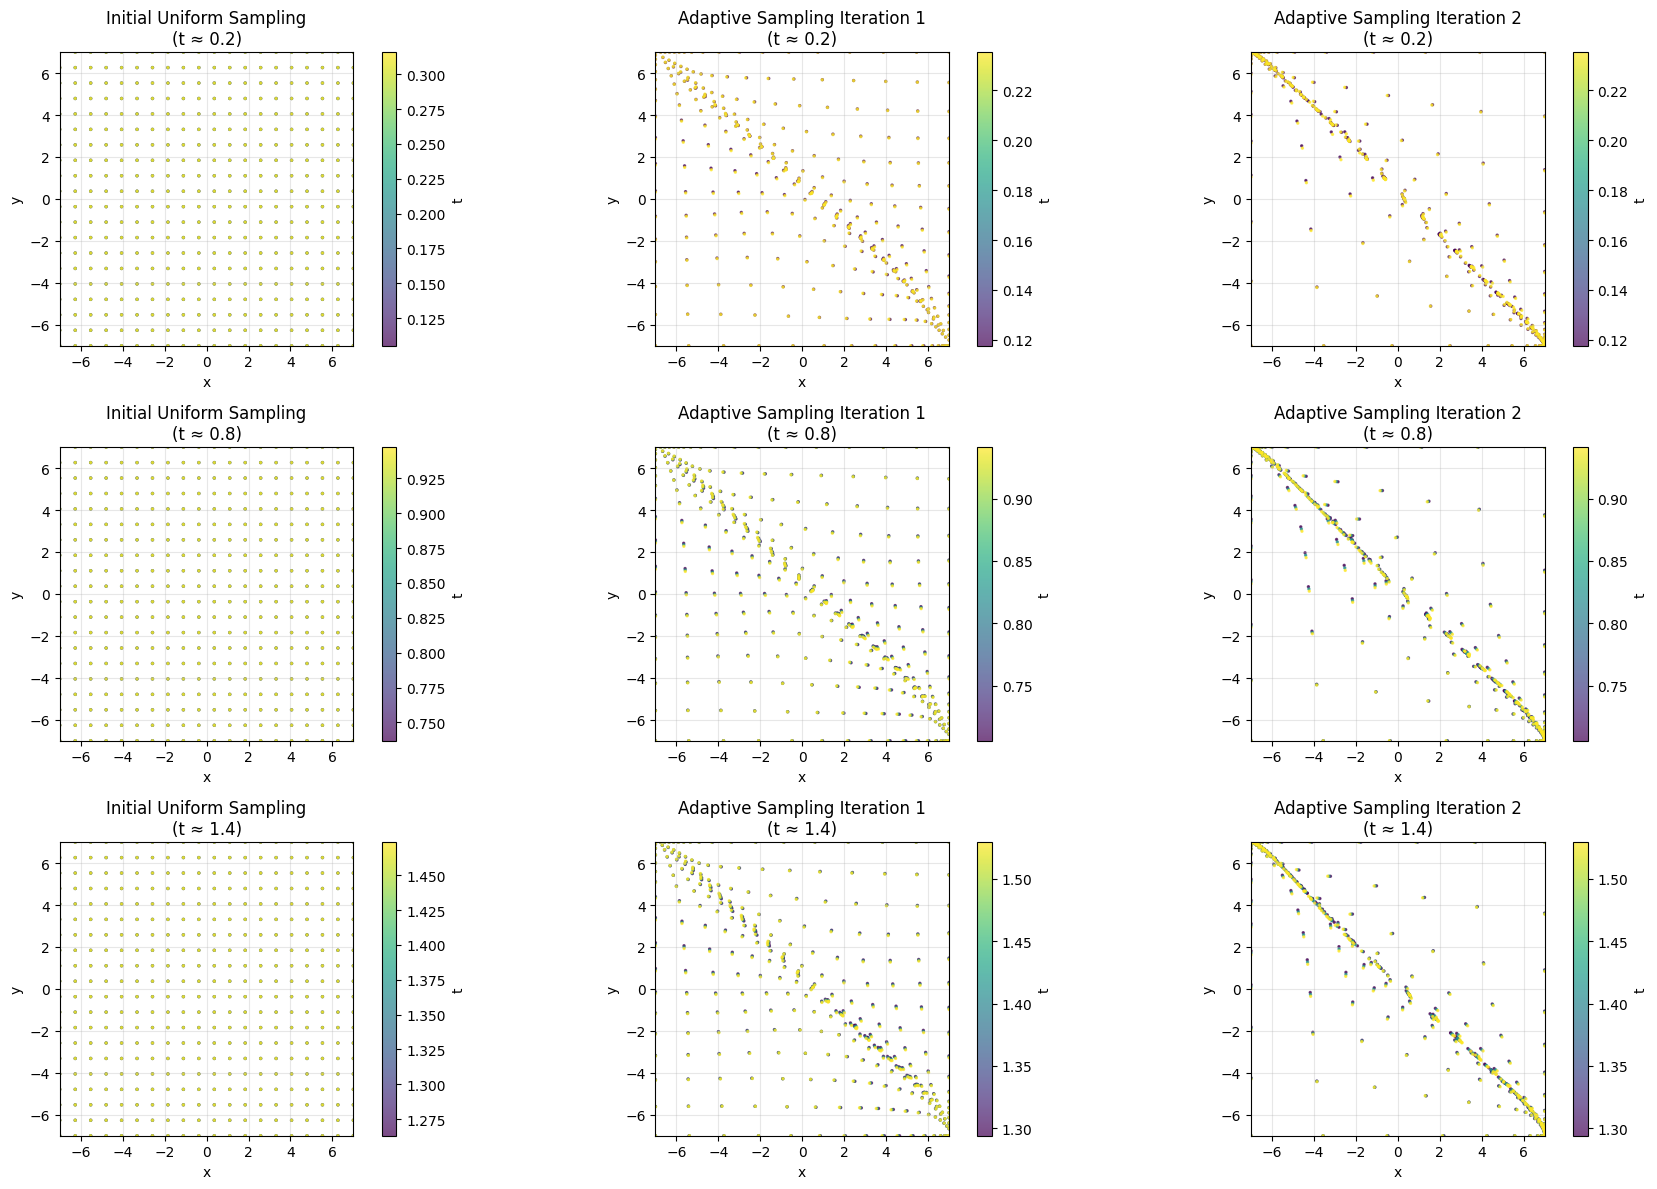


Iterative training completed!
Training completed!


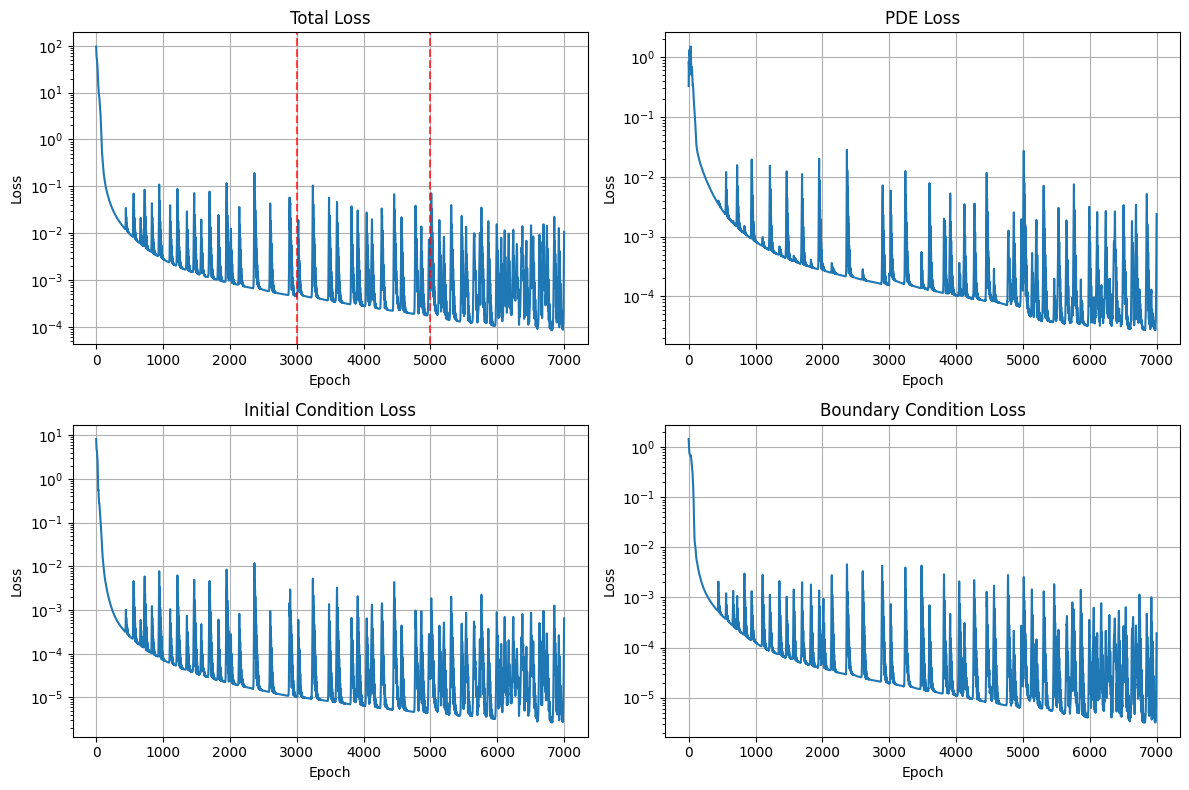


Evaluating model accuracy...
u - MSE: 1.277279e-03, Max Error: 5.573571e-02
v - MSE: 7.632473e-04, Max Error: 4.829478e-02

Final Results:
u displacement - MSE: 1.277279e-03
v velocity - MSE: 7.632473e-04
Maximum errors - u: 5.573571e-02, v: 4.829478e-02


In [3]:
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import OrderedDict

################################################################################
# PINN for the 2D Sine-Gordon Equation (First-order System Form)
#
# PDE System:
#   du/dt = v
#   dv/dt = u_xx + u_yy - sin(u)
# Domain:
#   t in [0, T], x in [-7, 7], y in [-7, 7]
# Initial Conditions:
#   u(x, y, 0)  = 4*arctan(exp(x + y))
#   v(x, y, 0)  = -4*exp(x + y) / (1 + exp(2*x + 2*y))
# Boundary Conditions:
#   u(t, ±7, y) = 4*arctan(exp(±7 + y - t))
#   u(t, x, ±7) = 4*arctan(exp(x ± 7 - t))
# Analytical Solution:
#   u(x, y, t) = 4*arctan(exp(x + y - t))
################################################################################

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

################################################################################
# Hyperparameters / Problem Setup
################################################################################
Lx_min, Lx_max = -7.0, 7.0    # Spatial domain: x in [-7, 7]
Ly_min, Ly_max = -7.0, 7.0    # Spatial domain: y in [-7, 7]
T = 2.0                       # Temporal domain: t in [0, T]

n_collocation = 8000          # Number of collocation points inside domain
n_boundary    = 800           # Number of points for boundary conditions (each boundary)
n_initial     = 1600          # Number of points for initial conditions
hidden_layers = 6             # Number of hidden layers
neurons       = 64            # Neurons per hidden layer
learning_rate = 1e-3          # Learning rate for optimizer
num_epochs    = 15000         # Training epochs

################################################################################
# Analytical Solutions and Initial/Boundary Conditions
################################################################################
def analytical_solution_u(x, y, t):
    """Analytical solution: u(x,y,t) = 4*arctan(exp(x + y - t))"""
    return 4 * np.arctan(np.exp(x + y - t))

def analytical_solution_v(x, y, t):
    """Analytical solution for v = du/dt"""
    exp_term = np.exp(x + y - t)
    return -4 * exp_term / (1 + exp_term**2)

def initial_condition_u(x, y):
    """Initial condition for u: u(x,y,0) = 4*arctan(exp(x + y))"""
    return 4 * np.arctan(np.exp(x + y))

def initial_condition_v(x, y):
    """Initial condition for v: v(x,y,0) = -4*exp(x + y)/(1 + exp(2*x + 2*y))"""
    return -4 * np.exp(x + y) / (1 + np.exp(2*x + 2*y))

def neumann_boundary_condition_u_x(x, y, t):
    """Neumann boundary condition for ∂u/∂x at x boundaries"""
    return 4 * np.exp(x + y + t) / (np.exp(2*t) + np.exp(2*x + 2*y))

def neumann_boundary_condition_u_y(x, y, t):
    """Neumann boundary condition for ∂u/∂y at y boundaries"""
    return 4 * np.exp(x + y + t) / (np.exp(2*t) + np.exp(2*x + 2*y))

def neumann_boundary_condition_v_x(x, y, t):
    """Neumann boundary condition for ∂v/∂x at x boundaries"""
    # Calculate ∂v/∂x from analytical solution
    exp_term = np.exp(x + y - t)
    exp_2term = np.exp(2*(x + y - t))
    numerator = -4 * exp_term * (1 - exp_2term)
    denominator = (1 + exp_2term)**2
    return numerator / denominator

def neumann_boundary_condition_v_y(x, y, t):
    """Neumann boundary condition for ∂v/∂y at y boundaries"""
    # Same as ∂v/∂x due to symmetry in the analytical solution
    return neumann_boundary_condition_v_x(x, y, t)

################################################################################
# 2D MMPDE Sampling Class for 2D Sine-Gordon Equation
################################################################################
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()
        self.depth = len(layers) - 1
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

class sampling_MMPDE_2D():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        self.lb = torch.tensor(lb).float().to(device)
        self.ub = torch.tensor(ub).float().to(device)

        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)
        self.y_f = torch.tensor(X_f[:, 2:3], requires_grad=True).float().to(device)
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        self.dnn = DNN(layers).to(device)

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, t, x, y):
        """
        Monitor function for Sine-Gordon equation:
        Based on u_x² + u_y² + u_t² + 2(1 - cos(u))
        """
        t.requires_grad_(True)
        x.requires_grad_(True) 
        y.requires_grad_(True)
        
        inputs = torch.cat([t, x, y], dim=1)
        uv = self.fun(inputs)
        u = uv[:, [0]]  # displacement u
        v = uv[:, [1]]  # velocity v = u_t

        # Compute spatial gradients of u
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]
        
        u_y = torch.autograd.grad(
            u, y,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]

        # Handle potential None gradients
        if u_x is None:
            u_x = torch.zeros_like(u)
        if u_y is None:
            u_y = torch.zeros_like(u)

        # Monitor function for Sine-Gordon: sqrt(u_x² + u_y² + v² + 2(1 - cos(u)))
        w = torch.sqrt(u_x**2 + u_y**2 + v**2 + 2*(1 - torch.cos(u)) + 1e-8)
        
        return w

    def net_sample(self, t, x, y):
        """
        Generate new sampling points - adaptive adjustment for x and y coordinates
        For Neumann boundary conditions, we don't need special boundary handling
        """
        inputs = torch.cat([t, x, y], dim=1)
        xy_new = self.dnn(inputs)
        
        x_new = xy_new[:, [0]]
        y_new = xy_new[:, [1]]
        
        # Apply boundary constraints (coordinates stay within domain)
        gx0 = x - self.lb[1]  # x - x_min
        gx1 = x - self.ub[1]  # x - x_max
        gy0 = y - self.lb[2]  # y - y_min  
        gy1 = y - self.ub[2]  # y - y_max
        
        # Ensure new coordinates remain within domain boundaries
        x_new = gx0 * gx1 * x_new + x
        y_new = gy0 * gy1 * y_new + y
        
        return x_new, y_new

    def net_f(self, t, x, y):
        """Calculate residual of 2D MMPDE equations"""
        x_new, y_new = self.net_sample(t, x, y)

        # Time derivatives of new coordinates
        x_new_t = torch.autograd.grad(
            x_new, t,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_t = torch.autograd.grad(
            y_new, t,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        # Spatial derivatives of new coordinates
        x_new_x = torch.autograd.grad(
            x_new, x,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_y = torch.autograd.grad(
            x_new, y,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_x = torch.autograd.grad(
            y_new, x,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_y = torch.autograd.grad(
            y_new, y,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        # Second-order derivatives of new coordinates
        x_new_xx = torch.autograd.grad(
            x_new_x, x,
            grad_outputs=torch.ones_like(x_new_x),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_yy = torch.autograd.grad(
            x_new_y, y,
            grad_outputs=torch.ones_like(x_new_y),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_xx = torch.autograd.grad(
            y_new_x, x,
            grad_outputs=torch.ones_like(y_new_x),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_yy = torch.autograd.grad(
            y_new_y, y,
            grad_outputs=torch.ones_like(y_new_y),
            retain_graph=True,
            create_graph=True
        )[0]

        G = self.monitor(t, x, y)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_y = torch.autograd.grad(
            G, y,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        # 2D MMPDE equation residuals
        E_x = G_x * x_new_x + G_y * x_new_y + G * (x_new_xx + x_new_yy)
        f_x = x_new_t * self.nu * (G**2) * (x_new_x**2 + x_new_y**2) + E_x

        E_y = G_x * y_new_x + G_y * y_new_y + G * (y_new_xx + y_new_yy)
        f_y = y_new_t * self.nu * (G**2) * (y_new_x**2 + y_new_y**2) + E_y

        return f_x, f_y

    def loss_func(self):
        """Calculate loss function"""
        f_x, f_y = self.net_f(self.t_f, self.x_f, self.y_f)
        loss_f = torch.mean(f_x ** 2) + torch.mean(f_y ** 2)
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = '2D_MMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = '2D_MMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        """Training process"""
        print("Starting 2D MMPDE training for Sine-Gordon...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("2D MMPDE_Adam completed!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('2D MMPDE_LBFGS completed!')

        # Return new sampling points
        x_new, y_new = self.net_sample(self.t_f, self.x_f, self.y_f)
        new_sample = torch.cat([self.t_f, x_new, y_new], dim=1)
        return new_sample

################################################################################
# Neural Network Definition
################################################################################
class PINN(nn.Module):
    def __init__(self, layers, activation=nn.Tanh()):
        super(PINN, self).__init__()
        
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        
        self.activation = activation
        
        # Initialize weights (Xavier initialization)
        for m in self.linears:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # Forward pass
        for i in range(len(self.linears) - 1):
            x = self.activation(self.linears[i](x))
        # output: [u, v] where v = u_t
        x = self.linears[-1](x)
        return x

################################################################################
# Physics-Informed Loss Function (First-order System Form for Sine-Gordon)
################################################################################
def sine_gordon_pde_loss(model, t, x, y):
    """
    Compute PDE residual for the first-order Sine-Gordon system:
    du/dt = v
    dv/dt = u_xx + u_yy - sin(u)
    """
    t.requires_grad_(True)
    x.requires_grad_(True)
    y.requires_grad_(True)

    # NN output: [u, v]
    inputs = torch.cat((t, x, y), dim=1)
    uv = model(inputs)
    u = uv[:, [0]] 
    v = uv[:, [1]]  

    # First derivatives of u
    u_grads = torch.autograd.grad(u, inputs, 
                                 grad_outputs=torch.ones_like(u), 
                                 create_graph=True)[0]
    u_t = u_grads[:, [0]]
    u_x = u_grads[:, [1]]
    u_y = u_grads[:, [2]]

    # First derivatives of v
    v_grads = torch.autograd.grad(v, inputs,
                                 grad_outputs=torch.ones_like(v),
                                 create_graph=True)[0]
    v_t = v_grads[:, [0]]

    # Second spatial derivatives of u
    u_xx = torch.autograd.grad(u_x, x,
                              grad_outputs=torch.ones_like(u_x),
                              create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y,
                              grad_outputs=torch.ones_like(u_y),
                              create_graph=True)[0]

    # PDE residuals for the first-order Sine-Gordon system:
    # Equation 1: du/dt = v
    f_u = u_t - v
    
    # Equation 2: dv/dt = u_xx + u_yy - sin(u)
    f_v = v_t - (u_xx + u_yy - torch.sin(u))

    return torch.mean(f_u**2) + torch.mean(f_v**2)

def initial_condition_loss(model, t, x, y, uv_true):
    """Compute loss for initial conditions"""
    inputs = torch.cat((t, x, y), dim=1)
    uv_pred = model(inputs)
    ic_loss = torch.mean((uv_pred - uv_true)**2)
    return ic_loss

def neumann_boundary_condition_loss(model, boundary_pts):
    """
    Compute loss for Neumann boundary conditions (gradient constraints)
    """
    bc_loss = 0
    
    # Process x-direction boundaries (left and right)
    for boundary_name, (t, x, y, grad_true) in boundary_pts.items():
        if 'left' in boundary_name or 'right' in boundary_name:
            # For x boundaries, constrain ∂u/∂x and ∂v/∂x
            t.requires_grad_(True)
            x.requires_grad_(True)
            y.requires_grad_(True)
            
            inputs = torch.cat((t, x, y), dim=1)
            uv_pred = model(inputs)
            u_pred = uv_pred[:, [0]]
            v_pred = uv_pred[:, [1]]
            
            # Calculate ∂u/∂x and ∂v/∂x
            u_x_pred = torch.autograd.grad(u_pred, x, 
                                         grad_outputs=torch.ones_like(u_pred),
                                         create_graph=True, retain_graph=True)[0]
            v_x_pred = torch.autograd.grad(v_pred, x, 
                                         grad_outputs=torch.ones_like(v_pred),
                                         create_graph=True, retain_graph=True)[0]
            
            # Extract true gradient values (assuming they're packed in grad_true)
            u_x_true = grad_true[:, [0]]  # First column is ∂u/∂x
            v_x_true = grad_true[:, [1]]  # Second column is ∂v/∂x
            
            # Add gradient constraint loss
            bc_loss += torch.mean((u_x_pred - u_x_true)**2)
            bc_loss += torch.mean((v_x_pred - v_x_true)**2)
            
        elif 'bottom' in boundary_name or 'top' in boundary_name:
            # For y boundaries, constrain ∂u/∂y and ∂v/∂y
            t.requires_grad_(True)
            x.requires_grad_(True)
            y.requires_grad_(True)
            
            inputs = torch.cat((t, x, y), dim=1)
            uv_pred = model(inputs)
            u_pred = uv_pred[:, [0]]
            v_pred = uv_pred[:, [1]]
            
            # Calculate ∂u/∂y and ∂v/∂y
            u_y_pred = torch.autograd.grad(u_pred, y, 
                                         grad_outputs=torch.ones_like(u_pred),
                                         create_graph=True, retain_graph=True)[0]
            v_y_pred = torch.autograd.grad(v_pred, y, 
                                         grad_outputs=torch.ones_like(v_pred),
                                         create_graph=True, retain_graph=True)[0]
            
            # Extract true gradient values
            u_y_true = grad_true[:, [0]]  # First column is ∂u/∂y
            v_y_true = grad_true[:, [1]]  # Second column is ∂v/∂y
            
            # Add gradient constraint loss
            bc_loss += torch.mean((u_y_pred - u_y_true)**2)
            bc_loss += torch.mean((v_y_pred - v_y_true)**2)
    
    return bc_loss

def loss_function(model, collocation_pts, initial_pts, boundary_pts):
    """Compute total loss for the PINN"""
    # Unpack data
    t_coll, x_coll, y_coll = collocation_pts
    t_init, x_init, y_init, uv_init = initial_pts
    
    # PDE residual loss
    pde_loss = sine_gordon_pde_loss(model, t_coll, x_coll, y_coll)
    
    # Initial condition loss
    ic_loss = initial_condition_loss(model, t_init, x_init, y_init, uv_init)
    
    # Boundary condition loss - now using Neumann conditions
    bc_loss = neumann_boundary_condition_loss(model, boundary_pts)
    
    # Combine losses with appropriate weights
    total_loss = pde_loss + 10*ic_loss + 10*bc_loss  # Higher weights for constraints
    
    return total_loss, pde_loss, ic_loss, bc_loss

################################################################################
# Iterative Training Strategy: PINN + MMPDE Alternating Optimization
################################################################################
def create_2d_simulation_function_from_model(model):
    """Create simulation function based on current PINN model"""
    def simulation_function(txy):
        model.eval()
        txy = txy.to(device)
        if not txy.requires_grad:
            txy.requires_grad_(True)
        return model(txy)
    return simulation_function

def generate_uniform_collocation_points(n_points=n_collocation):
    """Generate uniformly distributed collocation points"""
    n_per_dim = int(np.cbrt(n_points))
    
    t_uniform = torch.linspace(0, T, n_per_dim, device=device)
    x_uniform = torch.linspace(Lx_min, Lx_max, n_per_dim, device=device)  
    y_uniform = torch.linspace(Ly_min, Ly_max, n_per_dim, device=device)
    
    T_grid, X_grid, Y_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, indexing='ij')
    
    t_coll = T_grid.reshape(-1, 1)
    x_coll = X_grid.reshape(-1, 1)
    y_coll = Y_grid.reshape(-1, 1)
    
    t_coll.requires_grad_(True)
    x_coll.requires_grad_(True)
    y_coll.requires_grad_(True)
    
    print(f"Generated uniform collocation grid: {n_per_dim}×{n_per_dim}×{n_per_dim} = {t_coll.shape[0]} points")
    
    return (t_coll, x_coll, y_coll)

def generate_initial_training_data():
    """Generate initial training data (uniform sampling)"""
    # Uniform collocation points
    collocation_pts = generate_uniform_collocation_points()
    
    # Initial condition points
    grid_size = int(np.sqrt(n_initial))
    x_init_grid, y_init_grid = np.meshgrid(
        np.linspace(Lx_min, Lx_max, grid_size), 
        np.linspace(Ly_min, Ly_max, grid_size)
    )
    x_init = x_init_grid.flatten().reshape(-1, 1)
    y_init = y_init_grid.flatten().reshape(-1, 1)
    t_init = np.zeros_like(x_init)
    
    # Initial conditions using the specified functions
    u_init = initial_condition_u(x_init, y_init)
    v_init = initial_condition_v(x_init, y_init)
    uv_init = np.column_stack((u_init.flatten(), v_init.flatten()))
    
    t_init = torch.tensor(t_init, dtype=torch.float32, device=device, requires_grad=True)
    x_init = torch.tensor(x_init, dtype=torch.float32, device=device, requires_grad=True)
    y_init = torch.tensor(y_init, dtype=torch.float32, device=device, requires_grad=True)
    uv_init = torch.tensor(uv_init, dtype=torch.float32, device=device)
    
    # Boundary condition points
    t_bound_values = torch.rand(n_boundary, 1, device=device) * T
    
    # Left boundary (x = -7)
    t_bound_left = t_bound_values.clone()
    x_bound_left = Lx_min * torch.ones(n_boundary, 1, device=device)
    y_bound_left = torch.rand(n_boundary, 1, device=device) * (Ly_max - Ly_min) + Ly_min
    
    # Right boundary (x = 7)
    t_bound_right = t_bound_values.clone()
    x_bound_right = Lx_max * torch.ones(n_boundary, 1, device=device)
    y_bound_right = torch.rand(n_boundary, 1, device=device) * (Ly_max - Ly_min) + Ly_min
    
    # Bottom boundary (y = -7)
    t_bound_bottom = t_bound_values.clone()
    x_bound_bottom = torch.rand(n_boundary, 1, device=device) * (Lx_max - Lx_min) + Lx_min
    y_bound_bottom = Ly_min * torch.ones(n_boundary, 1, device=device)
    
    # Top boundary (y = 7)
    t_bound_top = t_bound_values.clone()
    x_bound_top = torch.rand(n_boundary, 1, device=device) * (Lx_max - Lx_min) + Lx_min
    y_bound_top = Ly_max * torch.ones(n_boundary, 1, device=device)
    
    # Calculate Neumann boundary condition values using analytical gradients
    # Left boundary (x = -7): need ∂u/∂x and ∂v/∂x
    u_x_left = neumann_boundary_condition_u_x(x_bound_left.cpu().numpy(), y_bound_left.cpu().numpy(), t_bound_left.cpu().numpy())
    v_x_left = neumann_boundary_condition_v_x(x_bound_left.cpu().numpy(), y_bound_left.cpu().numpy(), t_bound_left.cpu().numpy())
    grad_bound_left = torch.tensor(np.column_stack((u_x_left.flatten(), v_x_left.flatten())), dtype=torch.float32, device=device)
    
    # Right boundary (x = 7): need ∂u/∂x and ∂v/∂x
    u_x_right = neumann_boundary_condition_u_x(x_bound_right.cpu().numpy(), y_bound_right.cpu().numpy(), t_bound_right.cpu().numpy())
    v_x_right = neumann_boundary_condition_v_x(x_bound_right.cpu().numpy(), y_bound_right.cpu().numpy(), t_bound_right.cpu().numpy())
    grad_bound_right = torch.tensor(np.column_stack((u_x_right.flatten(), v_x_right.flatten())), dtype=torch.float32, device=device)
    
    # Bottom boundary (y = -7): need ∂u/∂y and ∂v/∂y
    u_y_bottom = neumann_boundary_condition_u_y(x_bound_bottom.cpu().numpy(), y_bound_bottom.cpu().numpy(), t_bound_bottom.cpu().numpy())
    v_y_bottom = neumann_boundary_condition_v_y(x_bound_bottom.cpu().numpy(), y_bound_bottom.cpu().numpy(), t_bound_bottom.cpu().numpy())
    grad_bound_bottom = torch.tensor(np.column_stack((u_y_bottom.flatten(), v_y_bottom.flatten())), dtype=torch.float32, device=device)
    
    # Top boundary (y = 7): need ∂u/∂y and ∂v/∂y
    u_y_top = neumann_boundary_condition_u_y(x_bound_top.cpu().numpy(), y_bound_top.cpu().numpy(), t_bound_top.cpu().numpy())
    v_y_top = neumann_boundary_condition_v_y(x_bound_top.cpu().numpy(), y_bound_top.cpu().numpy(), t_bound_top.cpu().numpy())
    grad_bound_top = torch.tensor(np.column_stack((u_y_top.flatten(), v_y_top.flatten())), dtype=torch.float32, device=device)
    
    # Set gradients for boundary tensors
    for tensor in [t_bound_left, x_bound_left, y_bound_left,
                  t_bound_right, x_bound_right, y_bound_right,
                  t_bound_bottom, x_bound_bottom, y_bound_bottom,
                  t_bound_top, x_bound_top, y_bound_top]:
        tensor.requires_grad_(True)
    
    initial_pts = (t_init, x_init, y_init, uv_init)
    boundary_pts = {
        'left': (t_bound_left, x_bound_left, y_bound_left, grad_bound_left),
        'right': (t_bound_right, x_bound_right, y_bound_right, grad_bound_right),
        'bottom': (t_bound_bottom, x_bound_bottom, y_bound_bottom, grad_bound_bottom),
        'top': (t_bound_top, x_bound_top, y_bound_top, grad_bound_top)
    }
    
    return collocation_pts, initial_pts, boundary_pts

def generate_initial_samples_2d(n_samples=5000):
    """Generate initial sampling points for 2D domain"""
    n_per_dim = int(np.cbrt(n_samples))
    
    t_uniform = torch.linspace(0, T, n_per_dim)
    x_uniform = torch.linspace(Lx_min, Lx_max, n_per_dim)  
    y_uniform = torch.linspace(Ly_min, Ly_max, n_per_dim)
    
    T_grid, X_grid, Y_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, indexing='ij')
    
    t_init = T_grid.reshape(-1, 1)
    x_init = X_grid.reshape(-1, 1)
    y_init = Y_grid.reshape(-1, 1)
    
    X_f_init = torch.cat([t_init, x_init, y_init], dim=1).numpy()
    
    print(f"Generated MMPDE initial sampling grid: {n_per_dim}×{n_per_dim}×{n_per_dim} = {X_f_init.shape[0]} points")
    
    return X_f_init

def iterative_training_with_adaptive_sampling(
    initial_epochs=3000,      # Initial training epochs
    adaptive_epochs=2000,     # Training epochs after each adaptive sampling  
    num_iterations=3,         # Number of iterations
    mmpde_training_epochs=500 # MMPDE training epochs
):
    """
    Iterative training strategy:
    1. Train initial PINN model with uniform sampling
    2. Perform MMPDE adaptive sampling based on current model
    3. Continue training PINN with new sampling points
    4. Repeat steps 2-3
    """
    
    print("=" * 80)
    print("Starting iterative training: PINN + MMPDE adaptive sampling for Sine-Gordon")
    print("=" * 80)
    
    # ==================== Phase 1: Initial Training ====================
    print(f"\n【Phase 1】Initial training with uniform sampling ({initial_epochs} epochs)")
    
    # Create initial model
    layers = [3] + [neurons]*hidden_layers + [2]
    model = PINN(layers, activation=nn.Tanh()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Initial training data
    collocation_pts, initial_pts, boundary_pts = generate_initial_training_data()
    
    # Training history
    all_loss_history = []
    all_pde_loss_history = []
    all_ic_loss_history = []
    all_bc_loss_history = []
    sampling_iterations = []
    
    # Store sampling points history for visualization
    sampling_points_history = []
    
    # Save initial uniform sampling points
    t_coll, x_coll, y_coll = collocation_pts
    initial_samples = torch.cat([t_coll, x_coll, y_coll], dim=1).detach().cpu().numpy()
    sampling_points_history.append(("Initial Uniform Sampling", initial_samples))
    
    # Initial training
    print("Starting initial training...")
    for epoch in range(initial_epochs):
        optimizer.zero_grad()
        loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
        
        all_loss_history.append(loss.item())
        all_pde_loss_history.append(pde_loss.item())
        all_ic_loss_history.append(ic_loss.item())
        all_bc_loss_history.append(bc_loss.item())
        
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 500 == 0:
            print(f"Epoch [{epoch+1}/{initial_epochs}], Loss: {loss.item():.6e}, PDE: {pde_loss.item():.6e}, IC: {ic_loss.item():.6e}, BC: {bc_loss.item():.6e}")
    
    sampling_iterations.append(len(all_loss_history))
    print(f"Initial training completed, current loss: {loss.item():.6e}")
    
    # ==================== Iterative Phase: MMPDE + Continue Training ====================
    for iteration in range(num_iterations):
        print(f"\n【Phase {iteration+2}】Iteration {iteration+1}: MMPDE adaptive sampling + continue training")
        
        # MMPDE sampling based on current model
        print("Performing MMPDE adaptive sampling based on current PINN model...")
        
        # Use previous sampling points for MMPDE (except for first iteration)
        if iteration == 0:
            # First iteration: generate initial sampling points
            X_f_init = generate_initial_samples_2d(n_samples=6000)
            print("First iteration: using uniform initial sampling points")
        else:
            # Subsequent iterations: use previous adaptive sampling points
            X_f_init = new_samples.detach().cpu().numpy()
            print(f"Iteration {iteration+1}: using previous adaptive sampling points ({X_f_init.shape[0]} points)")
        
        # Create simulation function using current model
        current_sim_func = create_2d_simulation_function_from_model(model)
        
        # MMPDE parameters
        mmpde_layers_2d = [3, 50, 50, 50, 2]
        adam_iter = mmpde_training_epochs // 2
        lbfgs_iter = mmpde_training_epochs // 4
        
        # Create MMPDE sampler
        mmpde_sampler = sampling_MMPDE_2D(
            X_f=X_f_init,
            u_fun=current_sim_func,
            layers=mmpde_layers_2d,
            lb=[0.0, Lx_min, Ly_min],
            ub=[T, Lx_max, Ly_max],
            nu=0.1,
            AdamIter=adam_iter,
            LBFGSIter=lbfgs_iter
        )
        
        # Train MMPDE and get new sampling points
        new_samples = mmpde_sampler.train()
        
        # Save adaptive sampling points for visualization
        new_samples_np = new_samples.detach().cpu().numpy()
        sampling_points_history.append((f"Adaptive Sampling Iteration {iteration+1}", new_samples_np))
        
        print(f"Saved sampling points: {new_samples_np.shape[0]} points for iteration {iteration+1}")
        
        # Extract new collocation points
        t_colloc_new = new_samples[:, 0:1].clone().detach().requires_grad_(True)
        x_colloc_new = new_samples[:, 1:2].clone().detach().requires_grad_(True)
        y_colloc_new = new_samples[:, 2:3].clone().detach().requires_grad_(True)
        
        print(f"Obtained new adaptive sampling points: {new_samples.shape[0]} points")
        
        # Update collocation points (keep initial and boundary conditions unchanged)
        collocation_pts = (t_colloc_new, x_colloc_new, y_colloc_new)
        
        # Continue training with new sampling points
        print(f"Continuing training with new sampling points ({adaptive_epochs} epochs)...")
        for epoch in range(adaptive_epochs):
            optimizer.zero_grad()
            loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
            
            all_loss_history.append(loss.item())
            all_pde_loss_history.append(pde_loss.item())
            all_ic_loss_history.append(ic_loss.item())
            all_bc_loss_history.append(bc_loss.item())
            
            loss.backward()
            optimizer.step()
            
            if (epoch + 1) % 400 == 0:
                print(f"Epoch [{epoch+1}/{adaptive_epochs}], Loss: {loss.item():.6e}, PDE: {pde_loss.item():.6e}")
        
        sampling_iterations.append(len(all_loss_history))
        print(f"Iteration {iteration+1} completed, current loss: {loss.item():.6e}")
    
    # ==================== Visualize Sampling Evolution ====================
    print("\nGenerating sampling point visualization...")
    visualize_sampling_evolution(sampling_points_history)
    
    print("\n" + "=" * 80)
    print("Iterative training completed!")
    print("=" * 80)
    
    return model, {
        'loss_history': all_loss_history,
        'pde_loss_history': all_pde_loss_history,
        'ic_loss_history': all_ic_loss_history,
        'bc_loss_history': all_bc_loss_history,
        'sampling_iterations': sampling_iterations,
        'sampling_points_history': sampling_points_history
    }

def visualize_sampling_evolution(sampling_points_history, n_display_points=2000):
    """
    Visualize the evolution of sampling points
    
    Parameters:
    -----------
    sampling_points_history : list
        List containing (description, sampling_points_array) pairs
    n_display_points : int
        Number of points to display (randomly sampled to avoid overcrowding)
    """
    n_plots = len(sampling_points_history)
    
    # Create subplots
    fig = plt.figure(figsize=(6*n_plots, 12))
    
    # For better visualization, show point distribution at different time slices
    time_slices = [0.2, 0.8, 1.4]  # Representative time slices
    
    for time_idx, t_slice in enumerate(time_slices):
        for plot_idx, (title, points) in enumerate(sampling_points_history):
            # Select points close to specified time
            t_coords = points[:, 0]
            time_mask = np.abs(t_coords - t_slice) < 0.15  # Time tolerance
            
            if np.sum(time_mask) > 10:  # Ensure sufficient points
                filtered_points = points[time_mask]
                
                # Random sampling to avoid overcrowding
                if len(filtered_points) > n_display_points:
                    indices = np.random.choice(len(filtered_points), n_display_points, replace=False)
                    display_points = filtered_points[indices]
                else:
                    display_points = filtered_points
                
                # Create subplot
                ax = fig.add_subplot(len(time_slices), n_plots, time_idx*n_plots + plot_idx + 1)
                
                # Scatter plot
                scatter = ax.scatter(display_points[:, 1], display_points[:, 2], 
                                   c=display_points[:, 0], cmap='viridis', 
                                   s=2, alpha=0.7)
                
                ax.set_xlim(Lx_min, Lx_max)
                ax.set_ylim(Ly_min, Ly_max)
                ax.set_xlabel('x')
                ax.set_ylabel('y')
                ax.set_title(f'{title}\n(t ≈ {t_slice})')
                ax.grid(True, alpha=0.3)
                ax.set_aspect('equal')
                
                # Add colorbar
                plt.colorbar(scatter, ax=ax, label='t')
            else:
                # If insufficient points, show empty plot
                ax = fig.add_subplot(len(time_slices), n_plots, time_idx*n_plots + plot_idx + 1)
                ax.text(0.5, 0.5, 'Insufficient\nData Points', 
                       transform=ax.transAxes, ha='center', va='center')
                ax.set_xlim(Lx_min, Lx_max)
                ax.set_ylim(Ly_min, Ly_max)
                ax.set_xlabel('x')
                ax.set_ylabel('y')
                ax.set_title(f'{title}\n(t ≈ {t_slice})')
                ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def evaluate_model_accuracy(model, n_test_points=1000):
    """
    Evaluate model accuracy against analytical solution
    """
    print("\nEvaluating model accuracy...")
    
    # Generate test points
    t_test = torch.rand(n_test_points, 1, device=device) * T
    x_test = torch.rand(n_test_points, 1, device=device) * (Lx_max - Lx_min) + Lx_min
    y_test = torch.rand(n_test_points, 1, device=device) * (Ly_max - Ly_min) + Ly_min
    
    # Model predictions
    model.eval()
    with torch.no_grad():
        inputs_test = torch.cat([t_test, x_test, y_test], dim=1)
        uv_pred = model(inputs_test)
        u_pred = uv_pred[:, 0].cpu().numpy()
        v_pred = uv_pred[:, 1].cpu().numpy()
    
    # Analytical solutions
    t_np = t_test.cpu().numpy()
    x_np = x_test.cpu().numpy()
    y_np = y_test.cpu().numpy()
    
    u_exact = analytical_solution_u(x_np, y_np, t_np).flatten()
    v_exact = analytical_solution_v(x_np, y_np, t_np).flatten()
    
    # Calculate errors
    u_error = np.abs(u_pred - u_exact)
    v_error = np.abs(v_pred - v_exact)
    
    u_mse = np.mean(u_error**2)
    v_mse = np.mean(v_error**2)
    u_max_error = np.max(u_error)
    v_max_error = np.max(v_error)
    
    print(f"u - MSE: {u_mse:.6e}, Max Error: {u_max_error:.6e}")
    print(f"v - MSE: {v_mse:.6e}, Max Error: {v_max_error:.6e}")
    
    return {
        'u_mse': u_mse,
        'v_mse': v_mse,
        'u_max_error': u_max_error,
        'v_max_error': v_max_error
    }

def plot_training_history(training_history):
    """Plot training loss history"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Total loss
    axes[0,0].semilogy(training_history['loss_history'])
    axes[0,0].set_title('Total Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].grid(True)
    
    # Mark sampling iterations
    for iteration in training_history['sampling_iterations'][:-1]:
        axes[0,0].axvline(x=iteration, color='red', linestyle='--', alpha=0.7, label='Adaptive Sampling')
    
    # PDE loss
    axes[0,1].semilogy(training_history['pde_loss_history'])
    axes[0,1].set_title('PDE Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].grid(True)
    
    # Initial condition loss
    axes[1,0].semilogy(training_history['ic_loss_history'])
    axes[1,0].set_title('Initial Condition Loss')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Loss')
    axes[1,0].grid(True)
    
    # Boundary condition loss
    axes[1,1].semilogy(training_history['bc_loss_history'])
    axes[1,1].set_title('Boundary Condition Loss')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Loss')
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()

################################################################################
# Execute Iterative Training
################################################################################

if __name__ == "__main__":
    # Run iterative training
    trained_model, training_history = iterative_training_with_adaptive_sampling(
        initial_epochs=3000,      # Initial training epochs
        adaptive_epochs=2000,     # Training epochs after adaptive sampling
        num_iterations=2,         # Number of iterations
        mmpde_training_epochs=200 # MMPDE training epochs
    )

    print("Training completed!")
    
    # Plot training history
    plot_training_history(training_history)
    
    # Evaluate model accuracy
    accuracy_results = evaluate_model_accuracy(trained_model)
    
    print(f"\nFinal Results:")
    print(f"u displacement - MSE: {accuracy_results['u_mse']:.6e}")
    print(f"v velocity - MSE: {accuracy_results['v_mse']:.6e}")
    print(f"Maximum errors - u: {accuracy_results['u_max_error']:.6e}, v: {accuracy_results['v_max_error']:.6e}")

开始生成多时间切片对比图...
正在处理时间切片 t = 0.25
At t=0.25:
  Max |u error|: 5.538206e-02
  Mean |u error|: 2.835397e-02
  L2 |u error|: 3.419601e-02
正在处理时间切片 t = 0.5
At t=0.5:
  Max |u error|: 5.529703e-02
  Mean |u error|: 2.903198e-02
  L2 |u error|: 3.462656e-02
正在处理时间切片 t = 1.0
At t=1.0:
  Max |u error|: 5.545340e-02
  Mean |u error|: 2.998599e-02
  L2 |u error|: 3.539898e-02


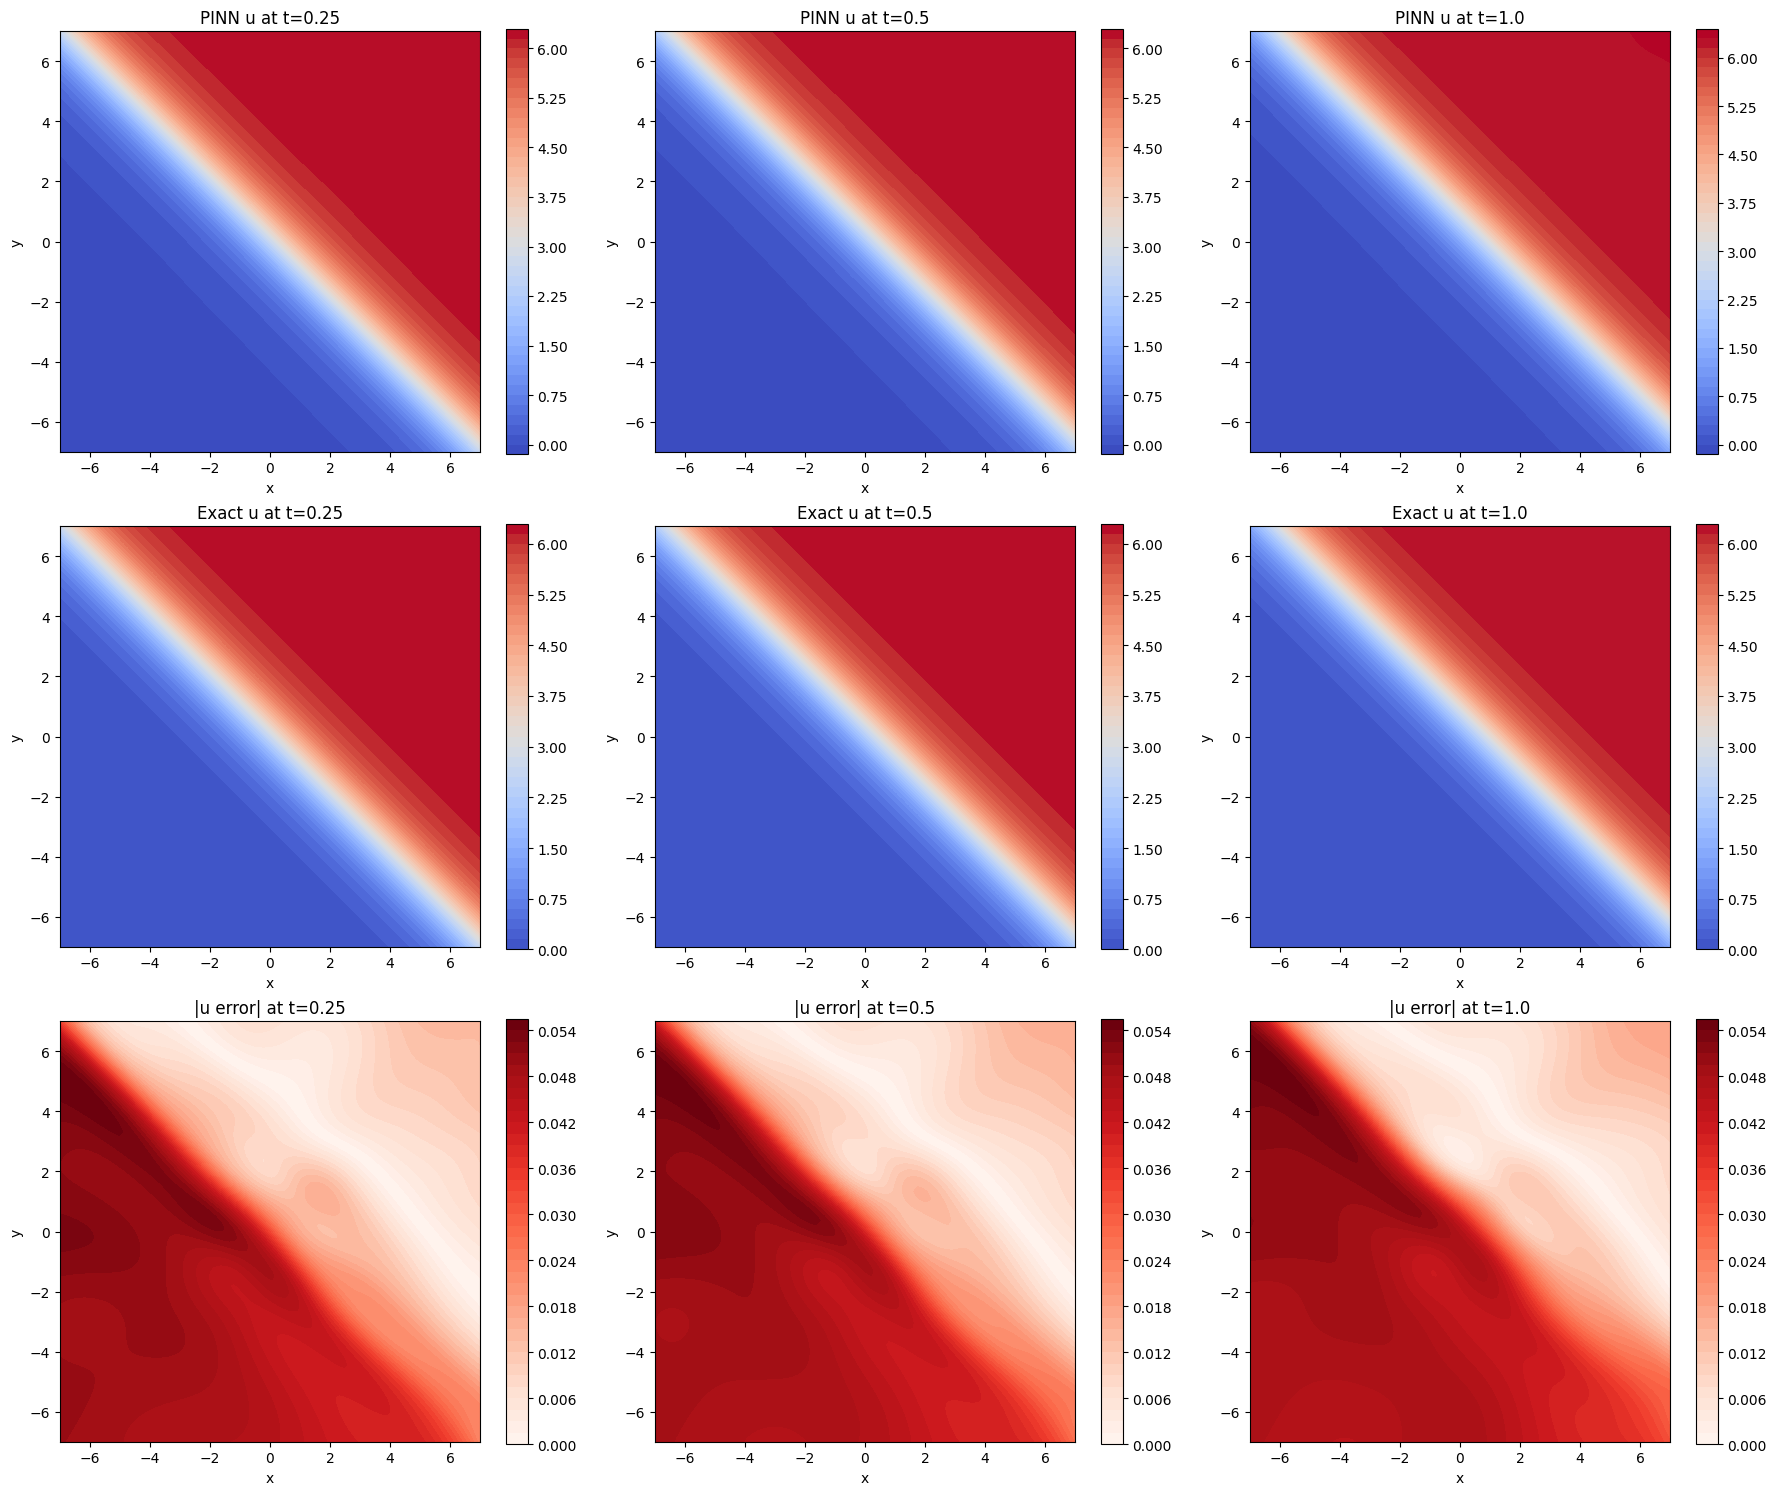


开始分析Sine-Gordon解的时间演化...
正在计算Sine-Gordon解的时间演化...
处理 t = 0.00 (1/10)
处理 t = 0.44 (3/10)
处理 t = 0.89 (5/10)
处理 t = 1.33 (7/10)
处理 t = 1.78 (9/10)

Sine-Gordon方程时间演化误差统计:
Time     Max u Error  Mean u Error L2 u Error   Max v Error  Mean v Error L2 v Error  
--------------------------------------------------------------------------------
0.00     5.551153e-02 2.751087e-02 3.373113e-02 4.788392e-02 2.308861e-02 2.616960e-02
0.22     5.535668e-02 2.826755e-02 3.415138e-02 4.782894e-02 2.300107e-02 2.623887e-02
0.44     5.529431e-02 2.889240e-02 3.453643e-02 4.826423e-02 2.303462e-02 2.634975e-02
0.67     5.529249e-02 2.939530e-02 3.489043e-02 4.889171e-02 2.320633e-02 2.650983e-02
0.89     5.537748e-02 2.980069e-02 3.522605e-02 4.933866e-02 2.350221e-02 2.673992e-02
1.11     5.554142e-02 3.014774e-02 3.556085e-02 4.967213e-02 2.393985e-02 2.706549e-02
1.33     5.573291e-02 3.048281e-02 3.591477e-02 4.989144e-02 2.454906e-02 2.751208e-02
1.56     5.587273e-02 3.085977e-02 3.630927e-02 4.981

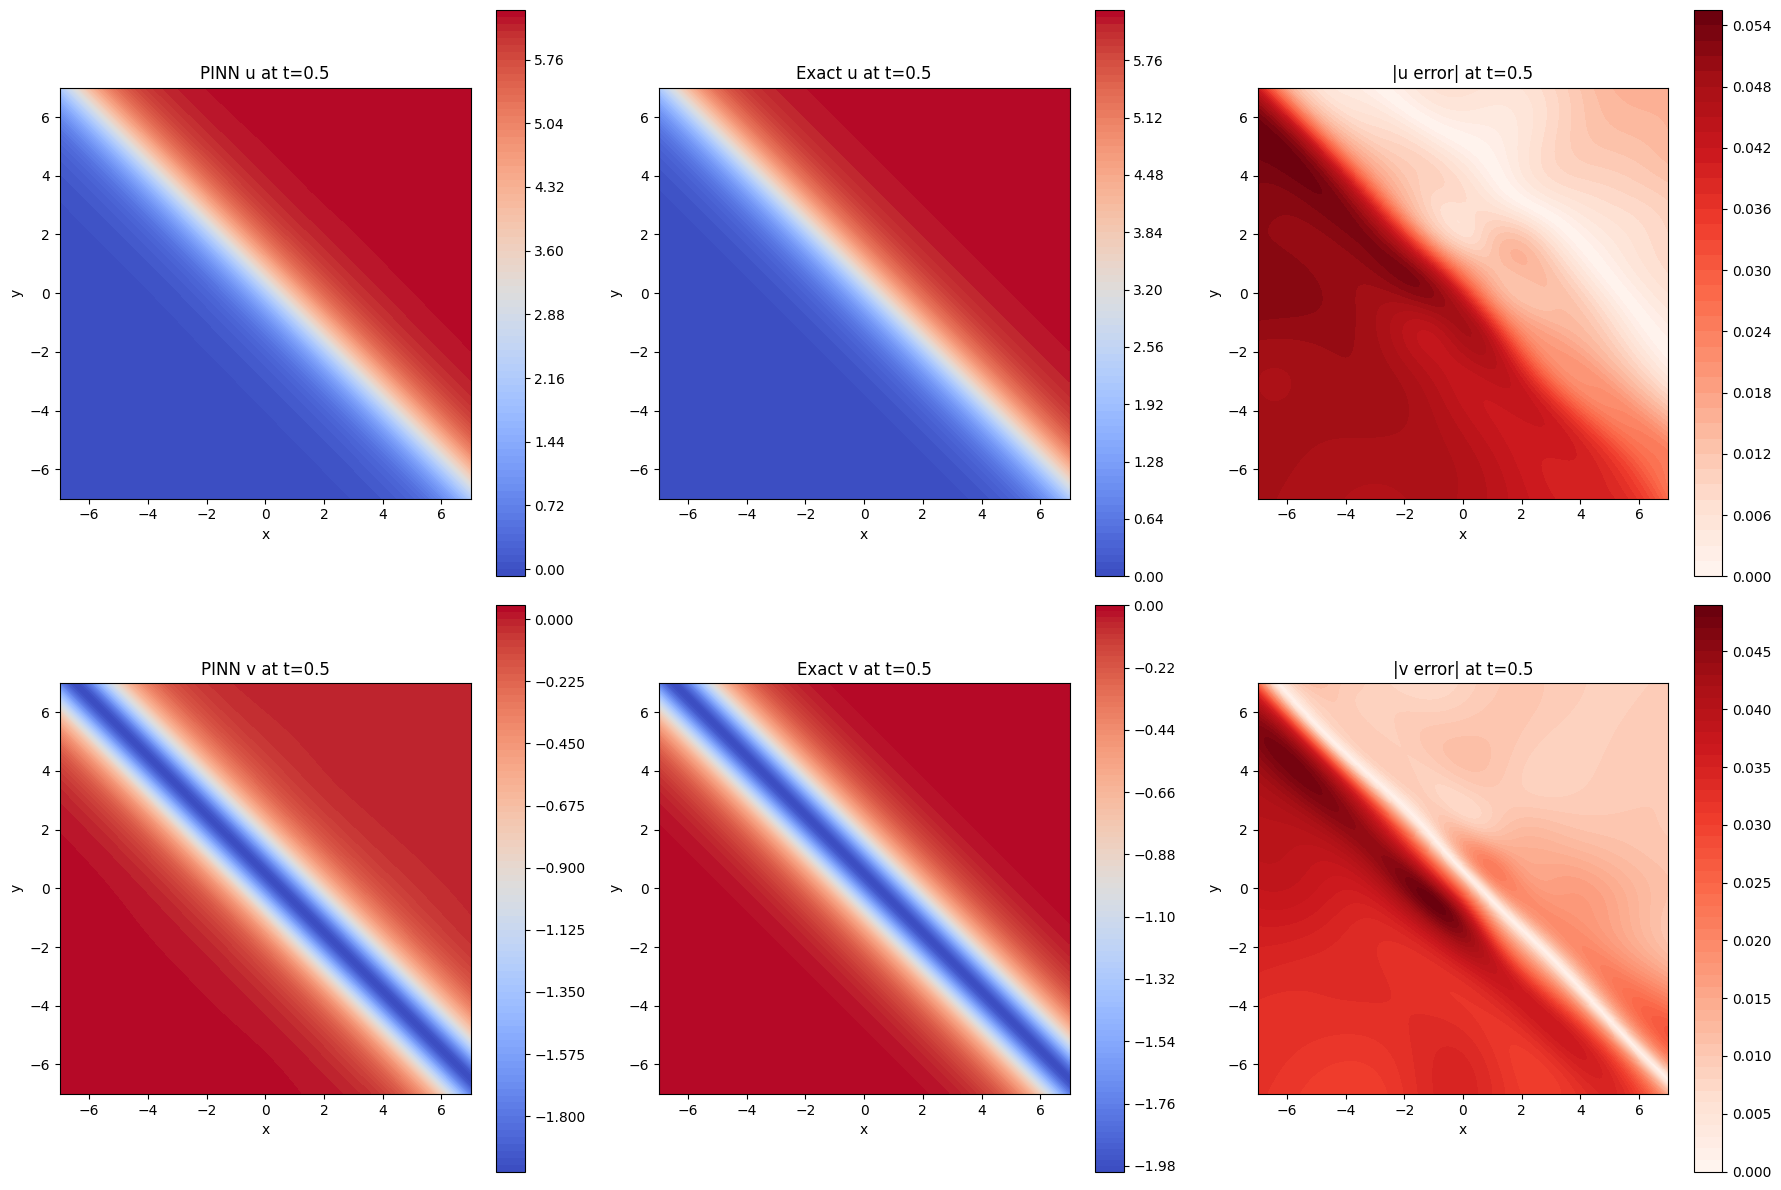


孤立子结构误差分析 (t=0.5):
u - Max error: 5.529856e-02, Mean error: 2.903310e-02, L2 error: 3.462629e-02
v - Max error: 4.868603e-02, Mean error: 2.308102e-02, L2 error: 2.639821e-02

绘制孤立子剖面对比...
绘制t=0.5时刻沿对角线的孤立子剖面...


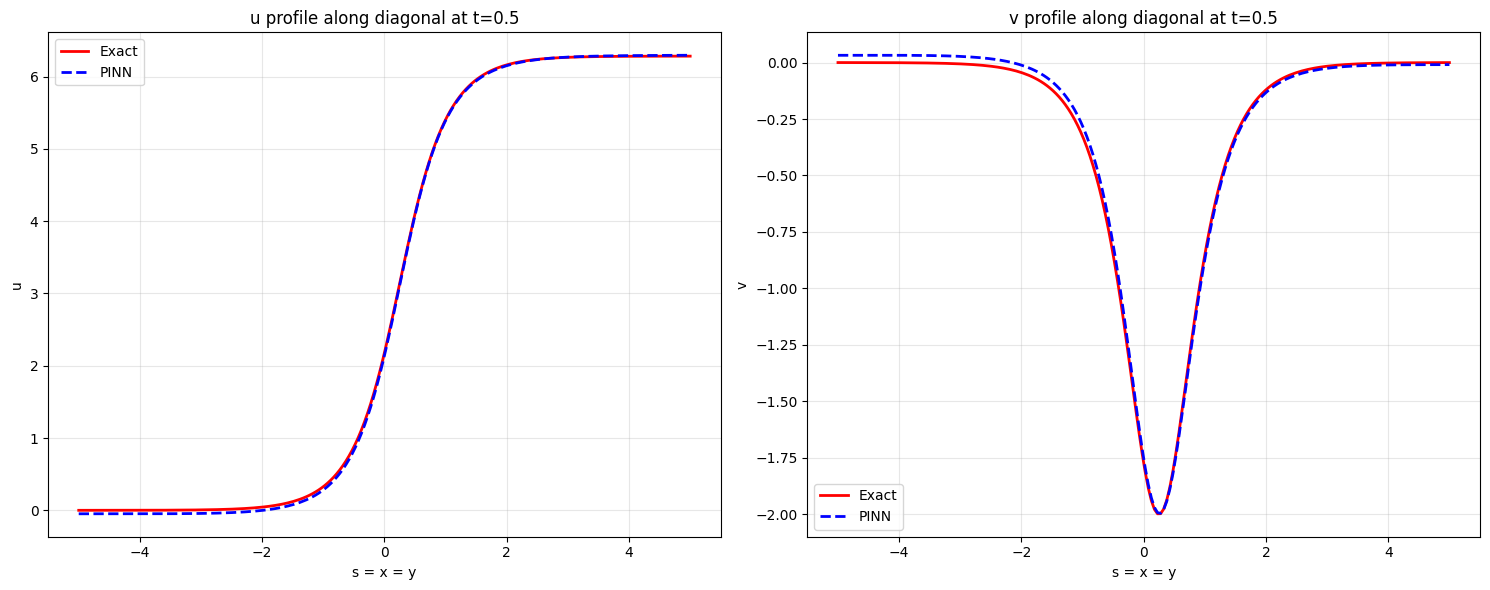

对角线剖面误差:
u - Max error: 4.921496e-02, Mean error: 2.932529e-02
v - Max error: 4.838597e-02, Mean error: 2.326876e-02


In [4]:
################################################################################
# 多时间切片解的可视化对比 - 针对Sine-Gordon方程修改
################################################################################
def visualize_multiple_time_slices(model, time_values=[0.25, 0.5, 1.0]):
    """
    绘制多个时间切片的解对比图 - 针对Sine-Gordon方程
    """
    n_times = len(time_values)
    
    # 创建网格 - 使用Sine-Gordon方程的域范围[-7, 7]
    x_grid = np.linspace(Lx_min, Lx_max, 100)
    y_grid = np.linspace(Ly_min, Ly_max, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # 创建大图：每个时间3行（u预测、u精确、u误差），每个时间1列
    fig, axes = plt.subplots(3, n_times, figsize=(6*n_times, 15))
    
    if n_times == 1:
        axes = axes.reshape(-1, 1)
    
    for time_idx, t_val in enumerate(time_values):
        print(f"正在处理时间切片 t = {t_val}")
        
        # 准备输入张量
        t_tensor = torch.full((X.size, 1), t_val, dtype=torch.float32, device=device)
        x_tensor = torch.tensor(X.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
        y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
        
        # PINN预测
        model.eval()
        with torch.no_grad():
            inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
            uv_pred = model(inputs).cpu().numpy()
            u_pred = uv_pred[:, 0].reshape(X.shape)
        
        # 精确解 - 使用Sine-Gordon方程的解析解
        u_exact = analytical_solution_u(X, Y, t_val)
        
        # 误差
        error_u = np.abs(u_pred - u_exact)
        
        # 设置颜色范围以便比较
        u_min = min(np.min(u_pred), np.min(u_exact))
        u_max = max(np.max(u_pred), np.max(u_exact))
        
        # PINN预测的u
        im1 = axes[0, time_idx].contourf(X, Y, u_pred, levels=50, cmap='coolwarm', 
                                        vmin=u_min, vmax=u_max)
        axes[0, time_idx].set_title(f'PINN u at t={t_val}')
        axes[0, time_idx].set_xlabel('x')
        axes[0, time_idx].set_ylabel('y')
        axes[0, time_idx].set_aspect('equal')
        plt.colorbar(im1, ax=axes[0, time_idx])
        
        # 精确解的u
        im2 = axes[1, time_idx].contourf(X, Y, u_exact, levels=50, cmap='coolwarm',
                                        vmin=u_min, vmax=u_max)
        axes[1, time_idx].set_title(f'Exact u at t={t_val}')
        axes[1, time_idx].set_xlabel('x')
        axes[1, time_idx].set_ylabel('y')
        axes[1, time_idx].set_aspect('equal')
        plt.colorbar(im2, ax=axes[1, time_idx])
        
        # 误差
        im3 = axes[2, time_idx].contourf(X, Y, error_u, levels=50, cmap='Reds')
        axes[2, time_idx].set_title(f'|u error| at t={t_val}')
        axes[2, time_idx].set_xlabel('x')
        axes[2, time_idx].set_ylabel('y')
        axes[2, time_idx].set_aspect('equal')
        plt.colorbar(im3, ax=axes[2, time_idx])
        
        # 打印误差统计
        print(f"At t={t_val}:")
        print(f"  Max |u error|: {np.max(error_u):.6e}")
        print(f"  Mean |u error|: {np.mean(error_u):.6e}")
        print(f"  L2 |u error|: {np.sqrt(np.mean(error_u**2)):.6e}")
    
    plt.tight_layout()
    plt.show()

def visualize_solution_evolution_animation_data(model, time_values=None):
    """
    生成解演化的数据用于分析 - 针对Sine-Gordon方程
    """
    if time_values is None:
        time_values = np.linspace(0, T, 10)
    
    # 创建网格 - 使用Sine-Gordon方程的域范围
    x_grid = np.linspace(Lx_min, Lx_max, 50)  # 降低分辨率以加快计算
    y_grid = np.linspace(Ly_min, Ly_max, 50)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # 存储数据
    results = {
        'time_values': time_values,
        'x_grid': X,
        'y_grid': Y,
        'u_pred_series': [],
        'u_exact_series': [],
        'v_pred_series': [],
        'v_exact_series': [],
        'error_u_series': [],
        'error_v_series': []
    }
    
    print("正在计算Sine-Gordon解的时间演化...")
    
    model.eval()
    for i, t_val in enumerate(time_values):
        if i % 2 == 0:  # 每两个时间步打印一次进度
            print(f"处理 t = {t_val:.2f} ({i+1}/{len(time_values)})")
        
        # 准备输入张量
        t_tensor = torch.full((X.size, 1), t_val, dtype=torch.float32, device=device)
        x_tensor = torch.tensor(X.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
        y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
        
        # PINN预测
        with torch.no_grad():
            inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
            uv_pred = model(inputs).cpu().numpy()
            u_pred = uv_pred[:, 0].reshape(X.shape)
            v_pred = uv_pred[:, 1].reshape(X.shape)
        
        # 精确解
        u_exact = analytical_solution_u(X, Y, t_val)
        v_exact = analytical_solution_v(X, Y, t_val)
        
        # 误差
        error_u = np.abs(u_pred - u_exact)
        error_v = np.abs(v_pred - v_exact)
        
        results['u_pred_series'].append(u_pred)
        results['u_exact_series'].append(u_exact)
        results['v_pred_series'].append(v_pred)
        results['v_exact_series'].append(v_exact)
        results['error_u_series'].append(error_u)
        results['error_v_series'].append(error_v)
    
    # 计算全局误差统计
    all_errors_u = np.array(results['error_u_series'])
    all_errors_v = np.array(results['error_v_series'])
    
    max_errors_u = [np.max(err) for err in all_errors_u]
    mean_errors_u = [np.mean(err) for err in all_errors_u]
    l2_errors_u = [np.sqrt(np.mean(err**2)) for err in all_errors_u]
    
    max_errors_v = [np.max(err) for err in all_errors_v]
    mean_errors_v = [np.mean(err) for err in all_errors_v]
    l2_errors_v = [np.sqrt(np.mean(err**2)) for err in all_errors_v]
    
    print("\nSine-Gordon方程时间演化误差统计:")
    print("=" * 80)
    print(f"{'Time':<8} {'Max u Error':<12} {'Mean u Error':<12} {'L2 u Error':<12} {'Max v Error':<12} {'Mean v Error':<12} {'L2 v Error':<12}")
    print("-" * 80)
    for t, max_u, mean_u, l2_u, max_v, mean_v, l2_v in zip(
        time_values, max_errors_u, mean_errors_u, l2_errors_u, 
        max_errors_v, mean_errors_v, l2_errors_v):
        print(f"{t:<8.2f} {max_u:<12.6e} {mean_u:<12.6e} {l2_u:<12.6e} {max_v:<12.6e} {mean_v:<12.6e} {l2_v:<12.6e}")
    
    return results

def visualize_soliton_structure(model, t_val=0.5):
    """
    可视化Sine-Gordon孤立子结构的细节
    """
    print(f"可视化t={t_val}时刻的孤立子结构...")
    
    # 创建高分辨率网格
    x_grid = np.linspace(Lx_min, Lx_max, 150)
    y_grid = np.linspace(Ly_min, Ly_max, 150)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # PINN预测
    t_tensor = torch.full((X.size, 1), t_val, dtype=torch.float32, device=device)
    x_tensor = torch.tensor(X.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
    y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
    
    model.eval()
    with torch.no_grad():
        inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
        uv_pred = model(inputs).cpu().numpy()
        u_pred = uv_pred[:, 0].reshape(X.shape)
        v_pred = uv_pred[:, 1].reshape(X.shape)
    
    # 精确解
    u_exact = analytical_solution_u(X, Y, t_val)
    v_exact = analytical_solution_v(X, Y, t_val)
    
    # 创建对比图
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # u的对比
    im1 = axes[0, 0].contourf(X, Y, u_pred, levels=100, cmap='coolwarm')
    axes[0, 0].set_title(f'PINN u at t={t_val}')
    axes[0, 0].set_xlabel('x')
    axes[0, 0].set_ylabel('y')
    axes[0, 0].set_aspect('equal')
    plt.colorbar(im1, ax=axes[0, 0])
    
    im2 = axes[0, 1].contourf(X, Y, u_exact, levels=100, cmap='coolwarm')
    axes[0, 1].set_title(f'Exact u at t={t_val}')
    axes[0, 1].set_xlabel('x')
    axes[0, 1].set_ylabel('y')
    axes[0, 1].set_aspect('equal')
    plt.colorbar(im2, ax=axes[0, 1])
    
    im3 = axes[0, 2].contourf(X, Y, np.abs(u_pred - u_exact), levels=50, cmap='Reds')
    axes[0, 2].set_title(f'|u error| at t={t_val}')
    axes[0, 2].set_xlabel('x')
    axes[0, 2].set_ylabel('y')
    axes[0, 2].set_aspect('equal')
    plt.colorbar(im3, ax=axes[0, 2])
    
    # v的对比
    im4 = axes[1, 0].contourf(X, Y, v_pred, levels=100, cmap='coolwarm')
    axes[1, 0].set_title(f'PINN v at t={t_val}')
    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('y')
    axes[1, 0].set_aspect('equal')
    plt.colorbar(im4, ax=axes[1, 0])
    
    im5 = axes[1, 1].contourf(X, Y, v_exact, levels=100, cmap='coolwarm')
    axes[1, 1].set_title(f'Exact v at t={t_val}')
    axes[1, 1].set_xlabel('x')
    axes[1, 1].set_ylabel('y')
    axes[1, 1].set_aspect('equal')
    plt.colorbar(im5, ax=axes[1, 1])
    
    im6 = axes[1, 2].contourf(X, Y, np.abs(v_pred - v_exact), levels=50, cmap='Reds')
    axes[1, 2].set_title(f'|v error| at t={t_val}')
    axes[1, 2].set_xlabel('x')
    axes[1, 2].set_ylabel('y')
    axes[1, 2].set_aspect('equal')
    plt.colorbar(im6, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.show()
    
    # 输出误差统计
    u_error = np.abs(u_pred - u_exact)
    v_error = np.abs(v_pred - v_exact)
    
    print(f"\n孤立子结构误差分析 (t={t_val}):")
    print(f"u - Max error: {np.max(u_error):.6e}, Mean error: {np.mean(u_error):.6e}, L2 error: {np.sqrt(np.mean(u_error**2)):.6e}")
    print(f"v - Max error: {np.max(v_error):.6e}, Mean error: {np.mean(v_error):.6e}, L2 error: {np.sqrt(np.mean(v_error**2)):.6e}")

def plot_soliton_profile_comparison(model, t_val=0.5):
    """
    绘制沿对角线的孤立子剖面对比
    """
    print(f"绘制t={t_val}时刻沿对角线的孤立子剖面...")
    
    # 沿对角线取点 (从(-5,-5)到(5,5))
    s = np.linspace(-5, 5, 200)
    x_line = s
    y_line = s
    
    # 准备输入
    t_tensor = torch.full((len(s), 1), t_val, dtype=torch.float32, device=device)
    x_tensor = torch.tensor(x_line, dtype=torch.float32, device=device).reshape(-1, 1)
    y_tensor = torch.tensor(y_line, dtype=torch.float32, device=device).reshape(-1, 1)
    
    # PINN预测
    model.eval()
    with torch.no_grad():
        inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
        uv_pred = model(inputs).cpu().numpy()
        u_pred = uv_pred[:, 0]
        v_pred = uv_pred[:, 1]
    
    # 精确解
    u_exact = analytical_solution_u(x_line, y_line, t_val)
    v_exact = analytical_solution_v(x_line, y_line, t_val)
    
    # 绘制剖面对比
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # u的剖面
    axes[0].plot(s, u_exact, 'r-', linewidth=2, label='Exact')
    axes[0].plot(s, u_pred, 'b--', linewidth=2, label='PINN')
    axes[0].set_xlabel('s = x = y')
    axes[0].set_ylabel('u')
    axes[0].set_title(f'u profile along diagonal at t={t_val}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # v的剖面
    axes[1].plot(s, v_exact, 'r-', linewidth=2, label='Exact')
    axes[1].plot(s, v_pred, 'b--', linewidth=2, label='PINN')
    axes[1].set_xlabel('s = x = y')
    axes[1].set_ylabel('v')
    axes[1].set_title(f'v profile along diagonal at t={t_val}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 计算剖面误差
    u_error = np.abs(u_pred - u_exact)
    v_error = np.abs(v_pred - v_exact)
    
    print(f"对角线剖面误差:")
    print(f"u - Max error: {np.max(u_error):.6e}, Mean error: {np.mean(u_error):.6e}")
    print(f"v - Max error: {np.max(v_error):.6e}, Mean error: {np.mean(v_error):.6e}")

# 使用示例（在训练完成后调用）
if __name__ == "__main__":
    # 假设已经有训练好的模型 trained_model
    
    # 可视化多个时间切片
    print("开始生成多时间切片对比图...")
    visualize_multiple_time_slices(trained_model, time_values=[0.25, 0.5, 1.0])
    
    # 分析解的时间演化
    print("\n开始分析Sine-Gordon解的时间演化...")
    evolution_data = visualize_solution_evolution_animation_data(trained_model)
    
    # 可视化孤立子结构
    print("\n可视化孤立子结构细节...")
    visualize_soliton_structure(trained_model, t_val=0.5)
    
    # 绘制剖面对比
    print("\n绘制孤立子剖面对比...")
    plot_soliton_profile_comparison(trained_model, t_val=0.5)

开始完整的Sine-Gordon PINN训练分析...
\n1. 绘制训练历史...


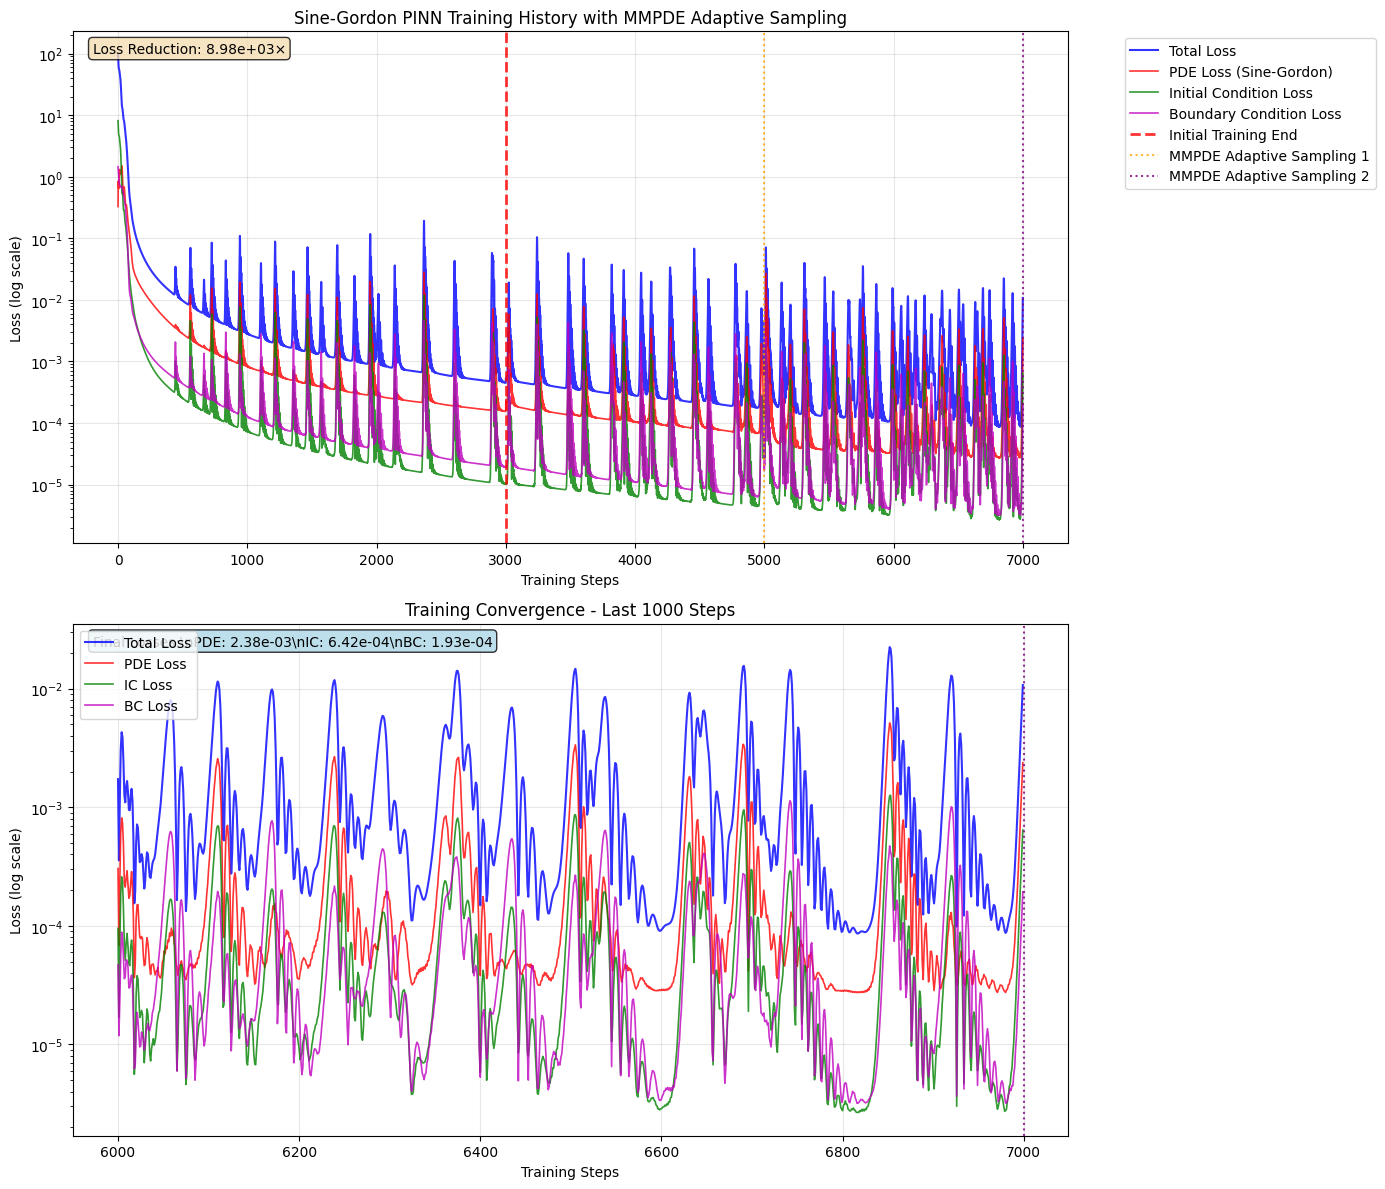

\n============================================================
Sine-Gordon PINN 训练总结
总训练步数: 7000
MMPDE自适应采样次数: 2
初始损失: 9.629051e+01
最终损失: 1.072855e-02
损失下降倍数: 8.98e+03
最终PDE损失: 2.375127e-03
最终IC损失: 6.421171e-04
最终BC损失: 1.932248e-04
\n自适应采样效果分析:
  第1次自适应采样: 损失改善 7.70e-01倍
  第2次自适应采样: 损失改善 6.47e-02倍
\n2. 分析损失分量演化...


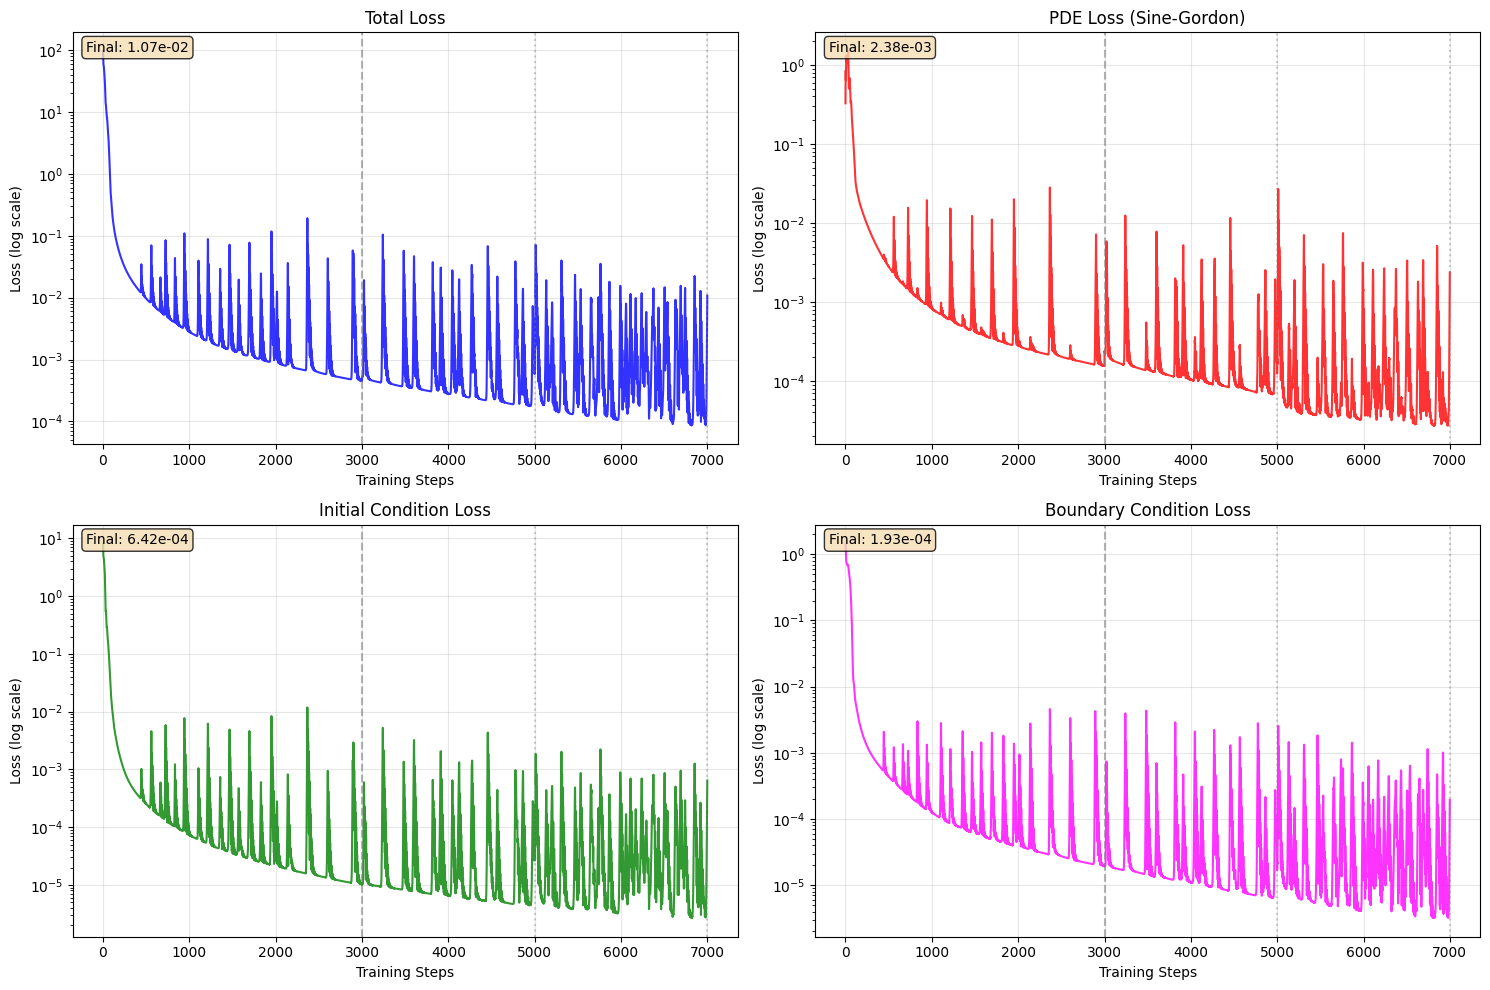

\n3. 进行收敛性分析...
\n==================================================
训练收敛性分析
\nInitial Training:
  Epochs: 5000
  Start idx: 0, End idx: 4999
  Loss improvement: 1.65e+05×
  Avg improvement per epoch: 1.0024×
\nAdaptive Stage 1:
  Epochs: 4000
  Start idx: 3000, End idx: 6999
  Loss improvement: 4.99e-02×
  Avg improvement per epoch: 0.9993×
\nAdaptive Stage 2:
  Epochs: 2000
  Start idx: 5000, End idx: 6999
  Loss improvement: 6.47e-02×
  Avg improvement per epoch: 0.9986×
\nMMPDE自适应采样总体效果:
  仅使用均匀采样的损失: 5.35e-04
  使用MMPDE后的最终损失: 1.07e-02
  MMPDE带来的额外改善: 4.99e-02×
\n4. 分析自适应采样影响...


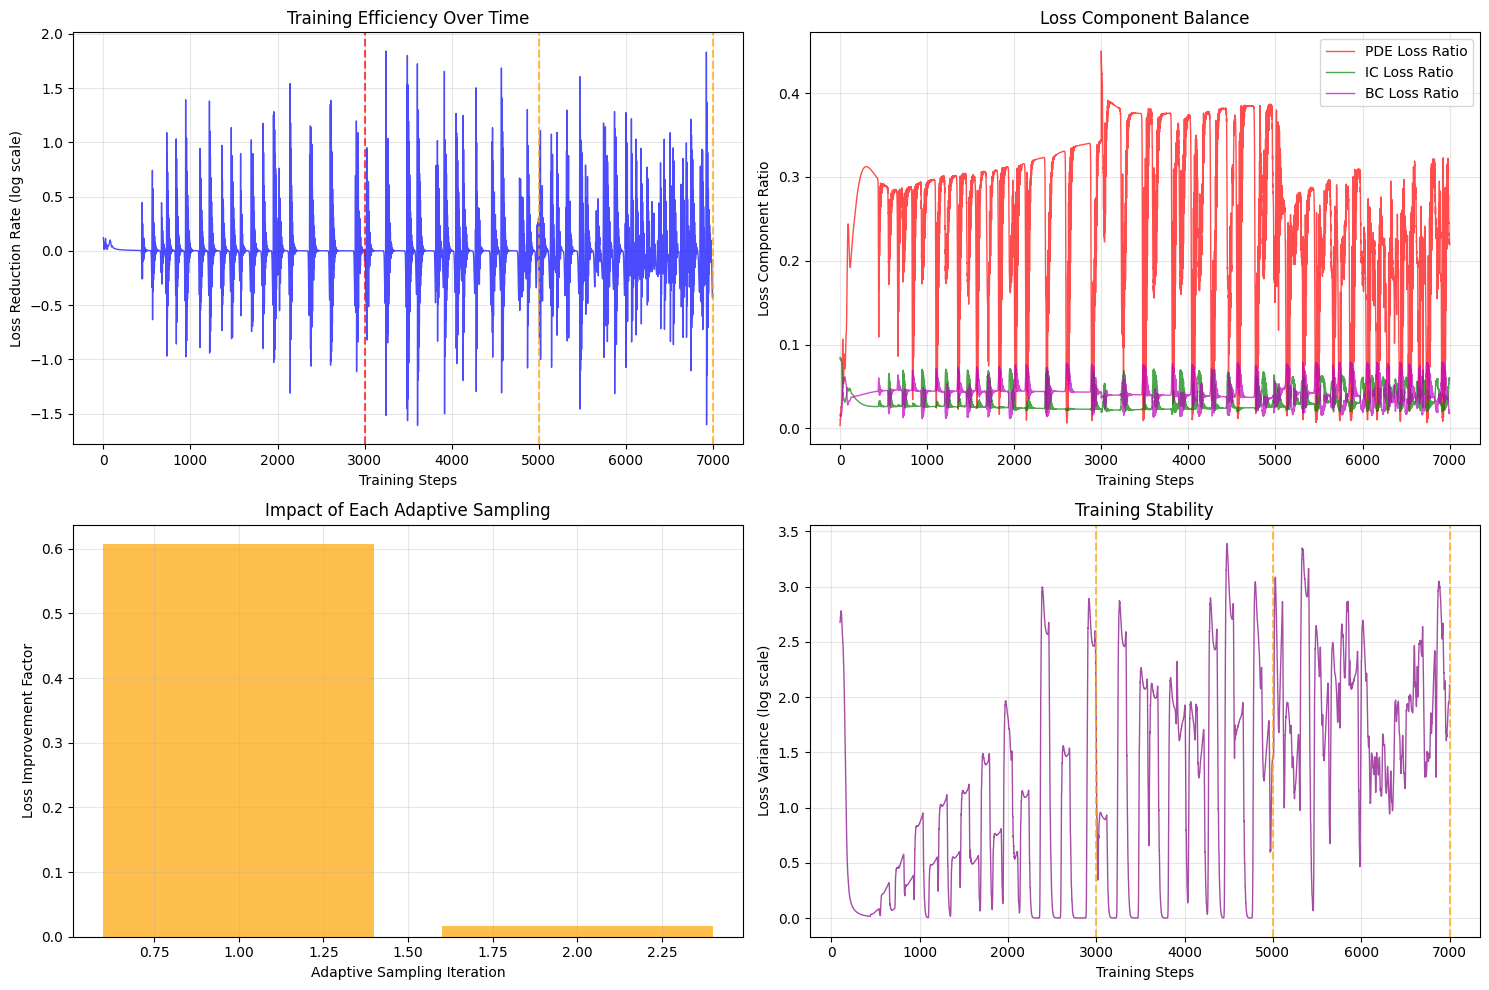

\n训练分析完成！


In [5]:
################################################################################
# 可视化训练历史（显示采样更新点） - 针对Sine-Gordon方程
################################################################################
def plot_training_history_with_sampling(history):
    """绘制带有采样更新标记的Sine-Gordon训练历史"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    
    # 绘制损失历史
    epochs = range(len(history['loss_history']))
    
    ax1.semilogy(epochs, history['loss_history'], 'b-', linewidth=1.5, label='Total Loss', alpha=0.8)
    ax1.semilogy(epochs, history['pde_loss_history'], 'r-', linewidth=1.2, label='PDE Loss (Sine-Gordon)', alpha=0.8)
    ax1.semilogy(epochs, history['ic_loss_history'], 'g-', linewidth=1.2, label='Initial Condition Loss', alpha=0.8)
    ax1.semilogy(epochs, history['bc_loss_history'], 'm-', linewidth=1.2, label='Boundary Condition Loss', alpha=0.8)
    
    # 添加采样更新的垂直线
    colors = ['red', 'orange', 'purple', 'brown']
    for i, update_point in enumerate(history['sampling_iterations']):
        if i < len(colors):
            color = colors[i]
        else:
            color = 'gray'
            
        if i == 0:
            label = 'Initial Training End'
            linestyle = '--'
            linewidth = 2
        else:
            label = f'MMPDE Adaptive Sampling {i}'
            linestyle = ':'
            linewidth = 1.5
            
        ax1.axvline(x=update_point, color=color, linestyle=linestyle, 
                   alpha=0.8, linewidth=linewidth, label=label)
    
    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Loss (log scale)')
    ax1.set_title('Sine-Gordon PINN Training History with MMPDE Adaptive Sampling')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # 计算并显示收敛率
    final_loss = history['loss_history'][-1]
    initial_loss = history['loss_history'][0]
    reduction_factor = initial_loss / final_loss
    ax1.text(0.02, 0.98, f'Loss Reduction: {reduction_factor:.2e}×', 
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # 绘制局部放大图（最后1000步或全部，取较小者）
    zoom_steps = min(1000, len(history['loss_history']) // 2)
    if len(history['loss_history']) > zoom_steps:
        start_idx = len(history['loss_history']) - zoom_steps
        epochs_zoom = range(start_idx, len(history['loss_history']))
        
        ax2.semilogy(epochs_zoom, history['loss_history'][start_idx:], 'b-', 
                    linewidth=1.5, label='Total Loss', alpha=0.8)
        ax2.semilogy(epochs_zoom, history['pde_loss_history'][start_idx:], 'r-', 
                    linewidth=1.2, label='PDE Loss', alpha=0.8)
        ax2.semilogy(epochs_zoom, history['ic_loss_history'][start_idx:], 'g-', 
                    linewidth=1.2, label='IC Loss', alpha=0.8)
        ax2.semilogy(epochs_zoom, history['bc_loss_history'][start_idx:], 'm-', 
                    linewidth=1.2, label='BC Loss', alpha=0.8)
        
        # 添加最后的采样更新线
        for i, update_point in enumerate(history['sampling_iterations']):
            if update_point >= start_idx:
                color = colors[min(i, len(colors)-1)]
                linestyle = '--' if i == 0 else ':'
                ax2.axvline(x=update_point, color=color, linestyle=linestyle, alpha=0.8)
        
        ax2.set_xlabel('Training Steps')
        ax2.set_ylabel('Loss (log scale)')
        ax2.set_title(f'Training Convergence - Last {zoom_steps} Steps')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 显示最终收敛状态
        final_pde_loss = history['pde_loss_history'][-1]
        final_ic_loss = history['ic_loss_history'][-1]
        final_bc_loss = history['bc_loss_history'][-1]
        
        ax2.text(0.02, 0.98, 
                f'Final Losses:\\nPDE: {final_pde_loss:.2e}\\nIC: {final_ic_loss:.2e}\\nBC: {final_bc_loss:.2e}', 
                transform=ax2.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig("sine_gordon_iterative_training_history.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印训练总结
    print("\\n" + "="*60)
    print("Sine-Gordon PINN 训练总结")
    print("="*60)
    print(f"总训练步数: {len(history['loss_history'])}")
    print(f"MMPDE自适应采样次数: {len(history['sampling_iterations'])-1}")
    print(f"初始损失: {history['loss_history'][0]:.6e}")
    print(f"最终损失: {history['loss_history'][-1]:.6e}")
    print(f"损失下降倍数: {history['loss_history'][0]/history['loss_history'][-1]:.2e}")
    print(f"最终PDE损失: {history['pde_loss_history'][-1]:.6e}")
    print(f"最终IC损失: {history['ic_loss_history'][-1]:.6e}")
    print(f"最终BC损失: {history['bc_loss_history'][-1]:.6e}")
    
    # 分析每次自适应采样的效果
    if len(history['sampling_iterations']) > 1:
        print(f"\\n自适应采样效果分析:")
        for i in range(1, len(history['sampling_iterations'])):
            start_idx = history['sampling_iterations'][i-1]
            end_idx = history['sampling_iterations'][i] if i < len(history['sampling_iterations'])-1 else len(history['loss_history'])-1
            
            if start_idx < len(history['loss_history']) and end_idx < len(history['loss_history']):
                loss_before = history['loss_history'][start_idx]
                loss_after = history['loss_history'][end_idx]
                improvement = loss_before / loss_after if loss_after > 0 else float('inf')
                print(f"  第{i}次自适应采样: 损失改善 {improvement:.2e}倍")

def plot_loss_components_evolution(history):
    """
    绘制各损失分量的演化趋势
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(len(history['loss_history']))
    
    # 各个损失分量
    loss_components = [
        ('loss_history', 'Total Loss', 'blue'),
        ('pde_loss_history', 'PDE Loss (Sine-Gordon)', 'red'),
        ('ic_loss_history', 'Initial Condition Loss', 'green'),
        ('bc_loss_history', 'Boundary Condition Loss', 'magenta')
    ]
    
    for idx, (loss_key, loss_name, color) in enumerate(loss_components):
        ax = axes[idx//2, idx%2]
        loss_data = history[loss_key]
        
        ax.semilogy(epochs, loss_data, color=color, linewidth=1.5, alpha=0.8)
        
        # 添加采样更新线
        for i, update_point in enumerate(history['sampling_iterations']):
            linestyle = '--' if i == 0 else ':'
            alpha = 0.6 if i == 0 else 0.4
            ax.axvline(x=update_point, color='gray', linestyle=linestyle, alpha=alpha)
        
        ax.set_xlabel('Training Steps')
        ax.set_ylabel('Loss (log scale)')
        ax.set_title(loss_name)
        ax.grid(True, alpha=0.3)
        
        # 显示最终值
        final_value = loss_data[-1]
        ax.text(0.02, 0.98, f'Final: {final_value:.2e}', 
               transform=ax.transAxes, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig("sine_gordon_loss_components.png", dpi=300, bbox_inches='tight')
    plt.show()

def analyze_training_convergence(history):
    """
    分析训练收敛特性
    """
    print("\\n" + "="*50)
    print("训练收敛性分析")
    print("="*50)
    
    total_epochs = len(history['loss_history'])
    
    # 分析各阶段的收敛率
    stages = []
    for i in range(len(history['sampling_iterations'])):
        start_idx = history['sampling_iterations'][i-1] if i > 0 else 0
        # 修复索引计算逻辑
        if i < len(history['sampling_iterations']) - 1:
            end_idx = history['sampling_iterations'][i+1] - 1
        else:
            end_idx = total_epochs - 1
        
        # 确保索引在有效范围内
        start_idx = max(0, min(start_idx, total_epochs - 1))
        end_idx = max(start_idx, min(end_idx, total_epochs - 1))
        
        stage_name = "Initial Training" if i == 0 else f"Adaptive Stage {i}"
        stages.append((stage_name, start_idx, end_idx))
    
    # 如果最后还有训练阶段
    if len(history['sampling_iterations']) > 0 and history['sampling_iterations'][-1] < total_epochs - 1:
        start_idx = history['sampling_iterations'][-1]
        end_idx = total_epochs - 1
        stages.append(("Final Training", start_idx, end_idx))
    
    for stage_name, start_idx, end_idx in stages:
        if end_idx > start_idx and start_idx < len(history['loss_history']) and end_idx < len(history['loss_history']):
            initial_loss = history['loss_history'][start_idx]
            final_loss = history['loss_history'][end_idx]
            epochs_in_stage = end_idx - start_idx + 1
            
            if final_loss > 0:
                improvement = initial_loss / final_loss
                avg_improvement_per_epoch = improvement ** (1.0 / epochs_in_stage)
                
                print(f"\\n{stage_name}:")
                print(f"  Epochs: {epochs_in_stage}")
                print(f"  Start idx: {start_idx}, End idx: {end_idx}")
                print(f"  Loss improvement: {improvement:.2e}×")
                print(f"  Avg improvement per epoch: {avg_improvement_per_epoch:.4f}×")
        else:
            print(f"\\n{stage_name}: Skipped (invalid indices: {start_idx}-{end_idx})")
    
    # 分析MMPDE采样的效果
    if len(history['sampling_iterations']) > 1:
        print(f"\\nMMPDE自适应采样总体效果:")
        uniform_end_idx = min(history['sampling_iterations'][0], len(history['loss_history']) - 1)
        uniform_loss = history['loss_history'][uniform_end_idx]
        final_loss = history['loss_history'][-1]
        mmpde_improvement = uniform_loss / final_loss
        print(f"  仅使用均匀采样的损失: {uniform_loss:.2e}")
        print(f"  使用MMPDE后的最终损失: {final_loss:.2e}")
        print(f"  MMPDE带来的额外改善: {mmpde_improvement:.2e}×")

def plot_sampling_impact_analysis(history):
    """
    分析自适应采样对训练的影响
    """
    if len(history['sampling_iterations']) <= 1:
        print("No adaptive sampling iterations to analyze.")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. 损失下降速率分析
    epochs = range(len(history['loss_history']))
    loss_gradient = np.gradient(np.log(history['loss_history']))
    
    axes[0, 0].plot(epochs, -loss_gradient, 'b-', linewidth=1, alpha=0.7)
    axes[0, 0].set_xlabel('Training Steps')
    axes[0, 0].set_ylabel('Loss Reduction Rate (log scale)')
    axes[0, 0].set_title('Training Efficiency Over Time')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 标记采样更新点
    for i, update_point in enumerate(history['sampling_iterations']):
        color = 'red' if i == 0 else 'orange'
        axes[0, 0].axvline(x=update_point, color=color, linestyle='--', alpha=0.7)
    
    # 2. 各损失分量的相对权重
    pde_ratio = np.array(history['pde_loss_history']) / np.array(history['loss_history'])
    ic_ratio = np.array(history['ic_loss_history']) / np.array(history['loss_history'])
    bc_ratio = np.array(history['bc_loss_history']) / np.array(history['loss_history'])
    
    axes[0, 1].plot(epochs, pde_ratio, 'r-', linewidth=1, label='PDE Loss Ratio', alpha=0.7)
    axes[0, 1].plot(epochs, ic_ratio, 'g-', linewidth=1, label='IC Loss Ratio', alpha=0.7)
    axes[0, 1].plot(epochs, bc_ratio, 'm-', linewidth=1, label='BC Loss Ratio', alpha=0.7)
    axes[0, 1].set_xlabel('Training Steps')
    axes[0, 1].set_ylabel('Loss Component Ratio')
    axes[0, 1].set_title('Loss Component Balance')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. 采样更新前后的改善分析
    improvements = []
    sampling_points = []
    
    for i in range(1, len(history['sampling_iterations'])):
        before_idx = max(0, history['sampling_iterations'][i-1] - 50)  # 采样前50步
        after_idx = min(len(history['loss_history'])-1, history['sampling_iterations'][i] + 50)  # 采样后50步
        
        if before_idx < len(history['loss_history']) and after_idx < len(history['loss_history']):
            loss_before = history['loss_history'][before_idx]
            loss_after = history['loss_history'][after_idx]
            improvement = loss_before / loss_after if loss_after > 0 else 1
            improvements.append(improvement)
            sampling_points.append(i)
    
    if improvements:
        axes[1, 0].bar(sampling_points, improvements, alpha=0.7, color='orange')
        axes[1, 0].set_xlabel('Adaptive Sampling Iteration')
        axes[1, 0].set_ylabel('Loss Improvement Factor')
        axes[1, 0].set_title('Impact of Each Adaptive Sampling')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 4. 训练稳定性分析（损失方差）
    window_size = 100
    if len(history['loss_history']) > window_size:
        loss_variance = []
        variance_epochs = []
        
        for i in range(window_size, len(history['loss_history'])):
            window_losses = history['loss_history'][i-window_size:i]
            variance = np.var(np.log(window_losses))
            loss_variance.append(variance)
            variance_epochs.append(i)
        
        axes[1, 1].plot(variance_epochs, loss_variance, 'purple', linewidth=1, alpha=0.7)
        axes[1, 1].set_xlabel('Training Steps')
        axes[1, 1].set_ylabel('Loss Variance (log scale)')
        axes[1, 1].set_title('Training Stability')
        axes[1, 1].grid(True, alpha=0.3)
        
        # 标记采样更新点
        for update_point in history['sampling_iterations']:
            if update_point > window_size:
                axes[1, 1].axvline(x=update_point, color='orange', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig("sine_gordon_sampling_impact_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

# 使用示例函数
def run_complete_training_analysis(training_history):
    """
    运行完整的训练分析流程
    """
    print("开始完整的Sine-Gordon PINN训练分析...")
    
    # 1. 基本训练历史
    print("\\n1. 绘制训练历史...")
    plot_training_history_with_sampling(training_history)
    
    # 2. 损失分量分析
    print("\\n2. 分析损失分量演化...")
    plot_loss_components_evolution(training_history)
    
    # 3. 收敛性分析
    print("\\n3. 进行收敛性分析...")
    analyze_training_convergence(training_history)
    
    # 4. 自适应采样影响分析
    print("\\n4. 分析自适应采样影响...")
    plot_sampling_impact_analysis(training_history)
    
    print("\\n训练分析完成！")

# 调用示例
if __name__ == "__main__":

    # 可以单独调用各个函数，也可以运行完整分析
    
    # 单独调用
    # plot_training_history_with_sampling(training_history)
    
    # 或者运行完整分析
    run_complete_training_analysis(training_history)